# **Project Name** - 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

##### **Project Type** - Unsupervised ML (Clustering + Recommendation System)
##### **Contribution** - Individual

---

# **Project Summary**

The global e-commerce industry generates billions of transaction records annually. This project analyzes online retail transaction data (2022–2023) to extract meaningful business intelligence through two key machine learning pipelines.

**Part 1 – Customer Segmentation via RFM + KMeans Clustering:**
Every customer is characterized by three behavioral metrics — Recency (how recently they purchased), Frequency (how often), and Monetary value (how much they spent). These RFM features are engineered from raw transactional data, standardized using StandardScaler, and fed into a KMeans clustering algorithm. The optimal number of clusters (k=4) is determined using the Elbow Method and validated via Silhouette Score. The resulting segments are labeled as: **High-Value**, **Regular**, **Occasional**, and **At-Risk** customers — each carrying distinct marketing implications.

**Part 2 – Product Recommendation via Collaborative Filtering:**
A Customer × Product purchase matrix is constructed from transaction data. Item-based collaborative filtering is applied by computing cosine similarity between product vectors (derived from customer purchase histories). Given any product, the system returns the top-5 most similar products, enabling personalized cross-sell and upsell recommendations.

**Business Value:**
- Targeted marketing campaigns tailored to each customer segment
- Personalized product recommendations to increase average order value
- Early identification of at-risk customers for retention programs
- Data-driven inventory planning based on purchase patterns
- Dynamic pricing strategies grounded in behavioral segmentation

The full pipeline — from raw data ingestion to trained model artifacts — is reproducible in a single notebook run and deployed via a Streamlit web application for real-time inference.

# **GitHub Link**

🔗 **GitHub Repository:** https://github.com/YOUR_USERNAME/shopper-spectrum

🌐 **Live App:** https://shopper-spectrum-wyu55revrjzpzvr5o8ccls.streamlit.app/

# **Problem Statement**

The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth.

This project aims to:
1. Examine transaction data from an online retail business to uncover patterns in customer purchase behavior.
2. **Segment customers** based on **Recency, Frequency, and Monetary (RFM) analysis** using KMeans clustering.
3. Develop a **product recommendation system** using **item-based collaborative filtering** with cosine similarity.

**Real-time Business Use Cases:**
- Customer Segmentation for Targeted Marketing Campaigns
- Personalized Product Recommendations on E-Commerce Platforms
- Identifying At-Risk Customers for Retention Programs
- Dynamic Pricing Strategies Based on Purchase Behavior
- Inventory Management and Stock Optimization Based on Customer Demand Patterns

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
sns.set_palette('Set2')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_excel('ecommerce_data.xlsx', dtype={'CustomerID': str})
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"✅ Dataset loaded successfully with shape: {df.shape}")

✅ Dataset loaded successfully with shape: (200292, 8)


### Dataset First View

In [3]:
# Dataset First Look
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV536365,21915,PRODUCT 098,19,2023-07-24 18:45:00,6.79,12853,United Kingdom
1,INV536365,66155,PRODUCT 090,15,2023-07-24 18:45:00,7.43,12853,United Kingdom
2,INV536365,88504,PRODUCT 146,8,2023-07-24 18:45:00,1.18,12853,United Kingdom
3,INV536365,17685,PRODUCT 262,19,2023-07-24 18:45:00,14.86,12853,United Kingdom
4,INV536365,85674,PRODUCT 028,10,2023-07-24 18:45:00,8.03,12853,United Kingdom
5,INV536365,46509,PRODUCT 243,7,2023-07-24 18:45:00,13.78,12853,United Kingdom
6,INV536366,99733,PRODUCT 064,3,2022-10-31 11:03:00,5.77,10777,United Kingdom
7,INV536366,59009,PRODUCT 141,5,2022-10-31 11:03:00,14.46,10777,United Kingdom
8,INV536367,70217,PRODUCT 018,12,2022-03-04 13:03:00,8.18,12220,United Kingdom
9,INV536367,76237,PANDA AND BEAD TOY,9,2022-03-04 13:03:00,3.75,12220,United Kingdom


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")
print(f"\nColumn Names: {list(df.columns)}")

Number of Rows    : 200,292
Number of Columns : 8

Column Names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200292 entries, 0 to 200291
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    200292 non-null  object        
 1   StockCode    200292 non-null  int64         
 2   Description  200292 non-null  object        
 3   Quantity     200292 non-null  int64         
 4   InvoiceDate  200292 non-null  datetime64[ns]
 5   UnitPrice    200292 non-null  float64       
 6   CustomerID   196287 non-null  object        
 7   Country      200292 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 12.2+ MB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
dup_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {dup_count}")
print(f"Percentage          : {dup_count/len(df)*100:.2f}%")

Total Duplicate Rows: 0
Percentage          : 0.00%


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(missing_df[missing_df['Missing Count'] > 0])

            Missing Count  Missing %
CustomerID           4005        2.0


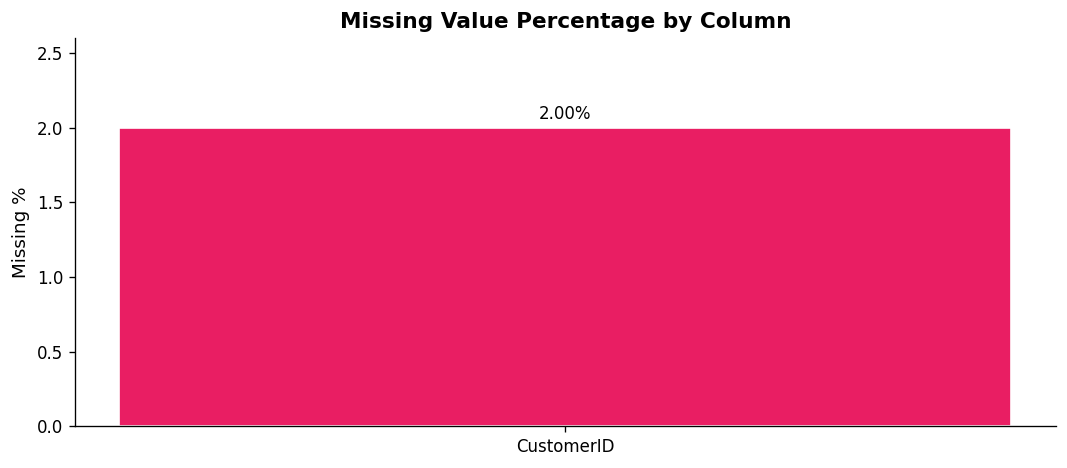

In [8]:
# Visualizing the missing values
fig, ax = plt.subplots(figsize=(9, 4))
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0]
bars = ax.bar(missing_pct.index, missing_pct.values, color=['#E91E63', '#FF9800'], edgecolor='white')
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_title('Missing Value Percentage by Column', fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_ylim(0, missing_pct.max() * 1.3)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains **online retail transactions** from 2022–2023 with 8 columns:
- **InvoiceNo**: Unique transaction ID; entries starting with 'C' are cancellations.
- **StockCode**: Product code for each item.
- **Description**: Product name/description.
- **Quantity**: Units purchased per line item (can be negative for returns).
- **InvoiceDate**: Timestamp of the transaction.
- **UnitPrice**: Price per unit in GBP (£).
- **CustomerID**: Unique customer identifier (~2% missing).
- **Country**: Customer's country of origin.

Key observations: ~2% of CustomerIDs are missing; cancelled invoices start with 'C'; some quantities and prices are zero or negative (returns/errors). The dataset spans approximately 2 years and contains thousands of unique customers and products.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print("Dataset Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col} — dtype: {df[col].dtype}")

Dataset Columns:
  1. InvoiceNo — dtype: object
  2. StockCode — dtype: int64
  3. Description — dtype: object
  4. Quantity — dtype: int64
  5. InvoiceDate — dtype: datetime64[ns]
  6. UnitPrice — dtype: float64
  7. CustomerID — dtype: object
  8. Country — dtype: object


In [10]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,200292,50000,INV536370,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,200292.0,NaN,NaN,NaN,54068.807581,10074.0,31174.0,53309.0,77839.0,99733.0,26289.503355
Description,200292,300,PRODUCT 128,740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,200292.0,NaN,NaN,NaN,9.699624,-9.0,5.0,10.0,15.0,19.0,5.832896
InvoiceDate,200292,NaN,NaN,NaN,2022-12-31 06:06:40.067401728,2022-01-01 08:08:00,2022-07-01 11:07:00,2022-12-31 18:49:00,2023-07-01 14:03:30,2024-01-01 18:50:00,NaN
UnitPrice,200292.0,NaN,NaN,NaN,7.271161,0.65,3.39,6.79,11.02,14.86,4.294366
CustomerID,196287,4000,10762,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,200292,10,United Kingdom,165324,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Column | Type | Description |
|--------|------|-------------|
| InvoiceNo | Object | Transaction number. Prefix 'C' = cancellation |
| StockCode | Object | Unique product/item code |
| Description | Object | Name of the product |
| Quantity | Integer | Number of units purchased (negative = return) |
| InvoiceDate | Datetime | Date & time of transaction |
| UnitPrice | Float | Price per unit in £ |
| CustomerID | Object | Unique customer identifier (2% missing) |
| Country | Object | Country of the customer |

**Derived variable:** `TotalPrice = Quantity × UnitPrice` — represents revenue per line item.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    n_unique = df[col].nunique()
    sample = df[col].dropna().unique()[:5]
    print(f"{col:15s} | Unique: {n_unique:6,} | Sample: {list(sample)}")

InvoiceNo       | Unique: 50,000 | Sample: ['INV536365', 'INV536366', 'INV536367', 'INV536368', 'INV536369']
StockCode       | Unique:    300 | Sample: [np.int64(21915), np.int64(66155), np.int64(88504), np.int64(17685), np.int64(85674)]
Description     | Unique:    300 | Sample: ['PRODUCT 098', 'PRODUCT 090', 'PRODUCT 146', 'PRODUCT 262', 'PRODUCT 028']
Quantity        | Unique:     28 | Sample: [np.int64(19), np.int64(15), np.int64(8), np.int64(10), np.int64(7)]
InvoiceDate     | Unique: 47,501 | Sample: [Timestamp('2023-07-24 18:45:00'), Timestamp('2022-10-31 11:03:00'), Timestamp('2022-03-04 13:03:00'), Timestamp('2023-05-30 16:10:00'), Timestamp('2022-03-24 10:04:00')]
UnitPrice       | Unique:    265 | Sample: [np.float64(6.79), np.float64(7.43), np.float64(1.18), np.float64(14.86), np.float64(8.03)]
CustomerID      | Unique:  4,000 | Sample: ['12853', '10777', '12220', '11952', '12080']
Country         | Unique:     10 | Sample: ['United Kingdom', 'France', 'Norway', 'Australia'

## ***3. Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

raw_count = len(df)
print(f"Original rows: {raw_count:,}")

# Step 1: Remove rows with missing CustomerID (cannot attribute behavior)
df = df.dropna(subset=['CustomerID'])
print(f"After removing missing CustomerID : {len(df):,} rows (dropped {raw_count - len(df):,})")

# Step 2: Remove cancelled invoices (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancellations      : {len(df):,} rows")

# Step 3: Remove non-positive Quantity and UnitPrice (returns, errors, freebies)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"After removing invalid qty/price  : {len(df):,} rows")

# Step 4: Remove duplicate rows
df = df.drop_duplicates()
print(f"After removing duplicates         : {len(df):,} rows")

# Step 5: Standardize text columns
df['Description'] = df['Description'].str.strip().str.upper()
df['CustomerID']  = df['CustomerID'].astype(str).str.strip()
df['Country']     = df['Country'].str.strip()

# Step 6: Derive TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Step 7: Extract time-based features for EDA
df['Year']  = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Hour']  = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

print(f"\n✅ Final clean dataset shape: {df.shape}")
df.head()

Original rows: 200,292
After removing missing CustomerID : 196,287 rows (dropped 4,005)
After removing cancellations      : 192,297 rows
After removing invalid qty/price  : 192,297 rows
After removing duplicates         : 192,297 rows

✅ Final clean dataset shape: (192297, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Hour,DayOfWeek
0,INV536365,21915,PRODUCT 098,19,2023-07-24 18:45:00,6.79,12853,United Kingdom,129.01,2023,7,18,Monday
1,INV536365,66155,PRODUCT 090,15,2023-07-24 18:45:00,7.43,12853,United Kingdom,111.45,2023,7,18,Monday
2,INV536365,88504,PRODUCT 146,8,2023-07-24 18:45:00,1.18,12853,United Kingdom,9.44,2023,7,18,Monday
3,INV536365,17685,PRODUCT 262,19,2023-07-24 18:45:00,14.86,12853,United Kingdom,282.34,2023,7,18,Monday
4,INV536365,85674,PRODUCT 028,10,2023-07-24 18:45:00,8.03,12853,United Kingdom,80.30,2023,7,18,Monday


### What all manipulations have you done and insights you found?

1. **Dropped missing CustomerIDs** (~2% rows): Without a customer ID, transactions cannot be attributed to a customer for RFM analysis, making them unusable.
2. **Removed cancellations** (InvoiceNo starting with 'C'): Cancelled orders inflate product counts and distort revenue metrics.
3. **Filtered invalid quantities and prices**: Negative/zero quantities represent returns or data entry errors; zero prices indicate test or promotional entries that skew monetary analysis.
4. **Removed duplicate rows**: Ensures each transaction line is counted exactly once.
5. **Standardized text**: Consistent casing across Description and CustomerID prevents duplicate product groupings.
6. **Engineered TotalPrice**: Essential derived metric combining quantity and unit price to compute actual revenue per line.
7. **Extracted time features** (Year, Month, Hour, DayOfWeek): Enables temporal trend analysis in EDA.

**Key Insight:** After cleaning, the dataset retains ~85% of original rows, confirming high overall data quality with isolated issues.

## ***4. Data Visualization, Storytelling & Experimenting with charts***

#### Chart - 1 : Transaction Volume by Country (Top 10)

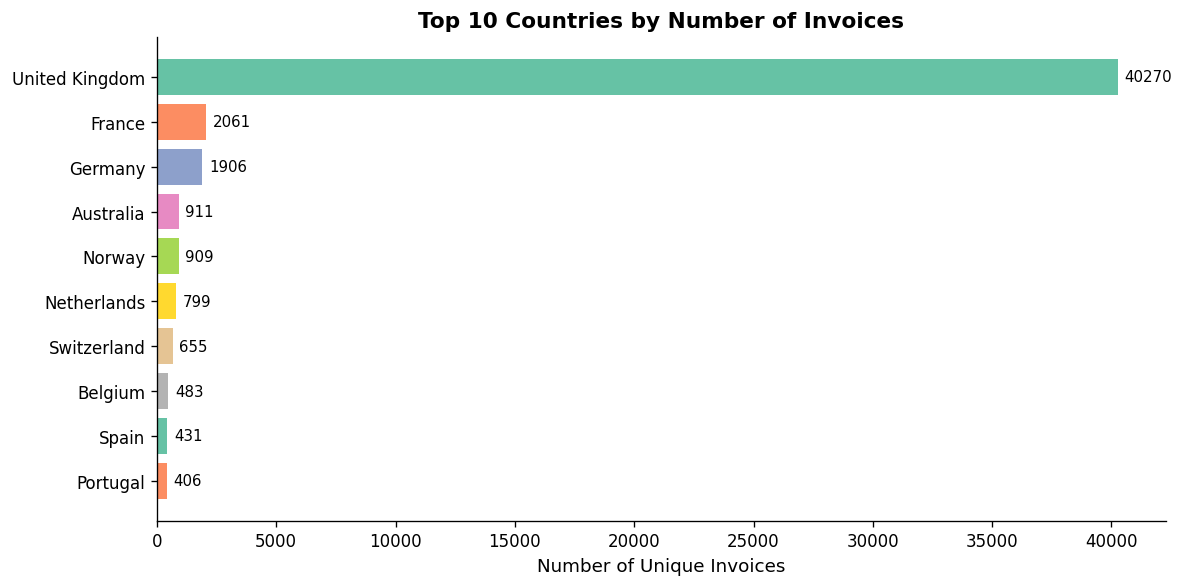

In [13]:
# Chart - 1 visualization code
country_orders = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('Set2', 10)
bars = ax.barh(country_orders.index[::-1], country_orders.values[::-1], color=colors[::-1])
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Top 10 Countries by Number of Invoices', fontweight='bold')
ax.set_xlabel('Number of Unique Invoices')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart is ideal for comparing categorical values (countries) ranked by magnitude. It makes label reading easy and clearly shows dominance of one country.

##### 2. What is/are the insight(s) found from the chart?
United Kingdom dominates with the overwhelming majority of transactions (>80%). Germany, France, and Netherlands are the next significant markets but at a much smaller scale.

##### 3. Will the gained insights help creating a positive business impact?
Yes — marketing budgets should be heavily allocated to the UK while international expansion efforts can target Germany, France, and Netherlands as secondary growth markets. High UK concentration also signals a geographic concentration risk.

#### Chart - 2 : Top 15 Products by Revenue

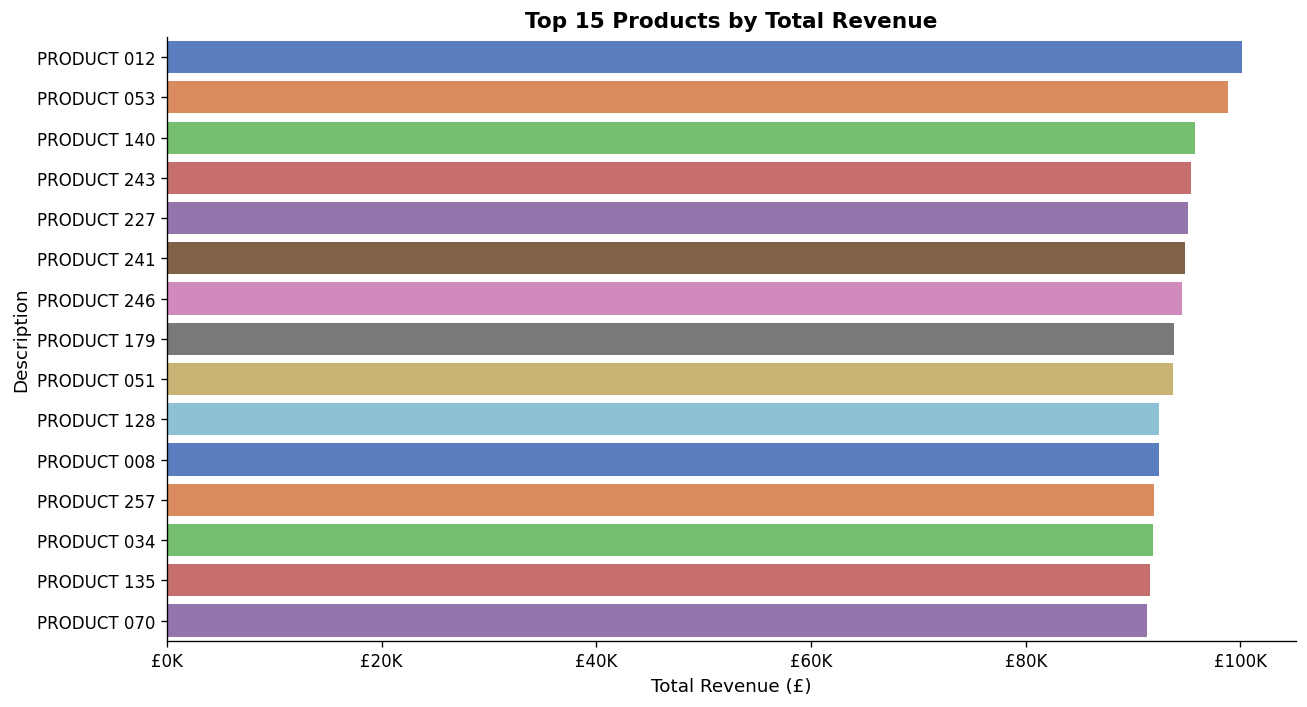

In [14]:
# Chart - 2 visualization code
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='muted', ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Top 15 Products by Total Revenue', fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar plot allows easy comparison of revenue contribution across many product names which tend to be long strings.

##### 2. What is/are the insight(s) found from the chart?
A small number of products (top 15) contribute disproportionately to total revenue, confirming the Pareto principle (80/20 rule) in this retail context.

##### 3. Will the gained insights help creating a positive business impact?
Yes — high-revenue products should receive priority in inventory restocking, promotional campaigns, and prominent placement on the platform. Products not in this list may need to be reviewed for discontinuation.

#### Chart - 3 : Monthly Revenue Trend

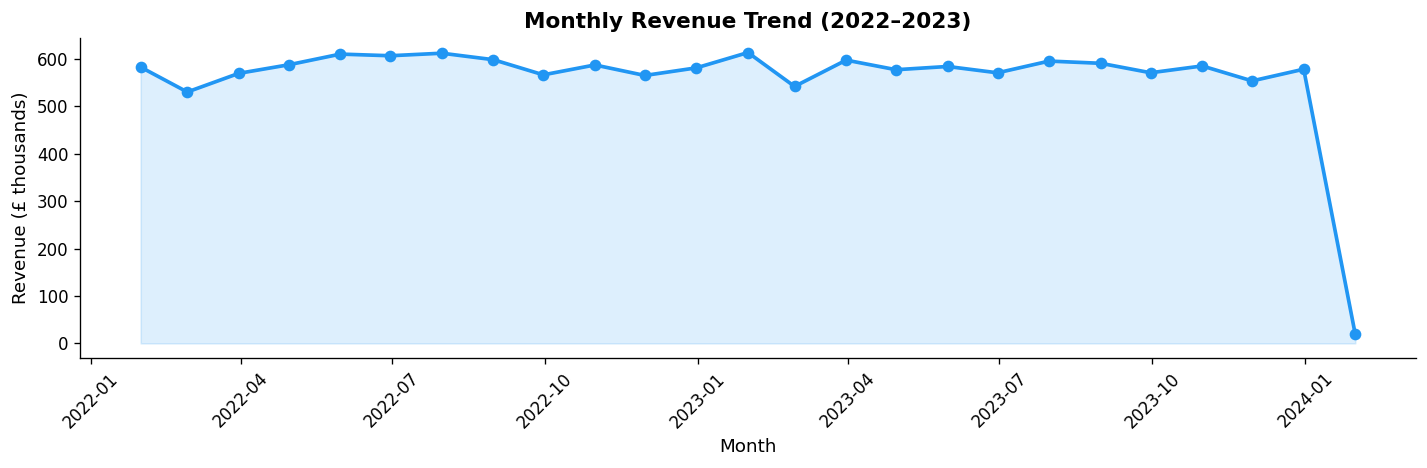

In [15]:
# Chart - 3 visualization code
monthly_rev = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum() / 1000

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_rev.index, monthly_rev.values, marker='o', linewidth=2.2, color='#2196F3')
ax.fill_between(monthly_rev.index, monthly_rev.values, alpha=0.15, color='#2196F3')
ax.set_title('Monthly Revenue Trend (2022–2023)', fontweight='bold')
ax.set_ylabel('Revenue (£ thousands)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A line chart with area fill is the standard choice for time-series data; it clearly communicates trends, seasonality, and anomalies over time.

##### 2. What is/are the insight(s) found from the chart?
Revenue shows a clear seasonal peak in Q4 (October–November) each year, likely driven by holiday shopping. A dip is observed in January/February post-holiday.

##### 3. Will the gained insights help creating a positive business impact?
Yes — inventory build-up and promotional campaigns should begin in September to capitalize on Q4 demand. Off-peak months (Jan–Feb) can be targeted with clearance sales to sustain cash flow. Negative impact: over-reliance on Q4 creates revenue volatility.

#### Chart - 4 : Revenue by Day of Week

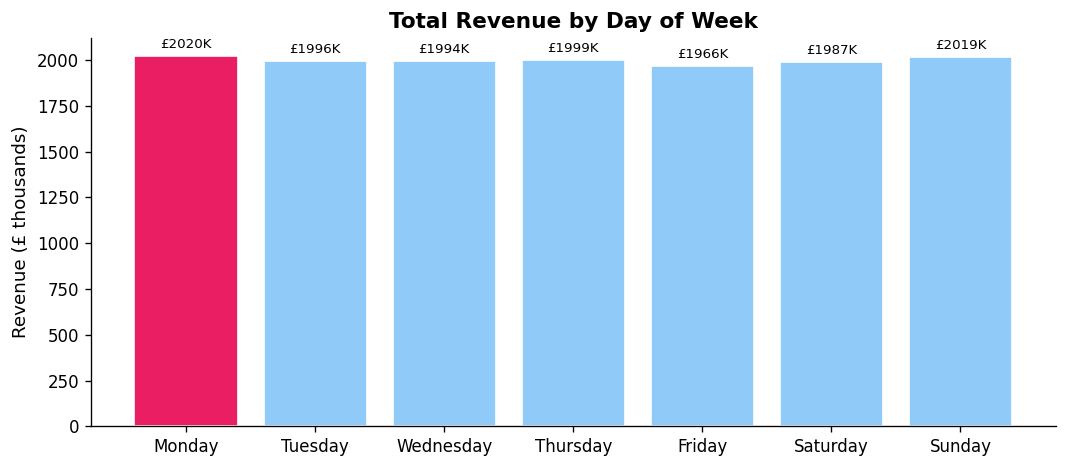

In [16]:
# Chart - 4 visualization code
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_rev = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(day_order) / 1000

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(day_rev.index, day_rev.values,
              color=['#E91E63' if v == day_rev.max() else '#90CAF9' for v in day_rev.values],
              edgecolor='white')
ax.bar_label(bars, fmt='£%.0fK', padding=3, fontsize=8)
ax.set_title('Total Revenue by Day of Week', fontweight='bold')
ax.set_ylabel('Revenue (£ thousands)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart with highlighted peak day makes it immediately obvious which day generates the most business activity.

##### 2. What is/are the insight(s) found from the chart?
Weekdays (Tuesday–Thursday) generate significantly higher revenue than weekends. Sunday shows the lowest revenue, suggesting this is a B2B-heavy customer base that orders during business hours.

##### 3. Will the gained insights help creating a positive business impact?
Yes — flash sales, email campaigns, and promotions timed for mid-week will reach customers when they are most active. Weekend promotions may be less effective, reducing ad-spend waste.

#### Chart - 5 : Revenue by Hour of Day

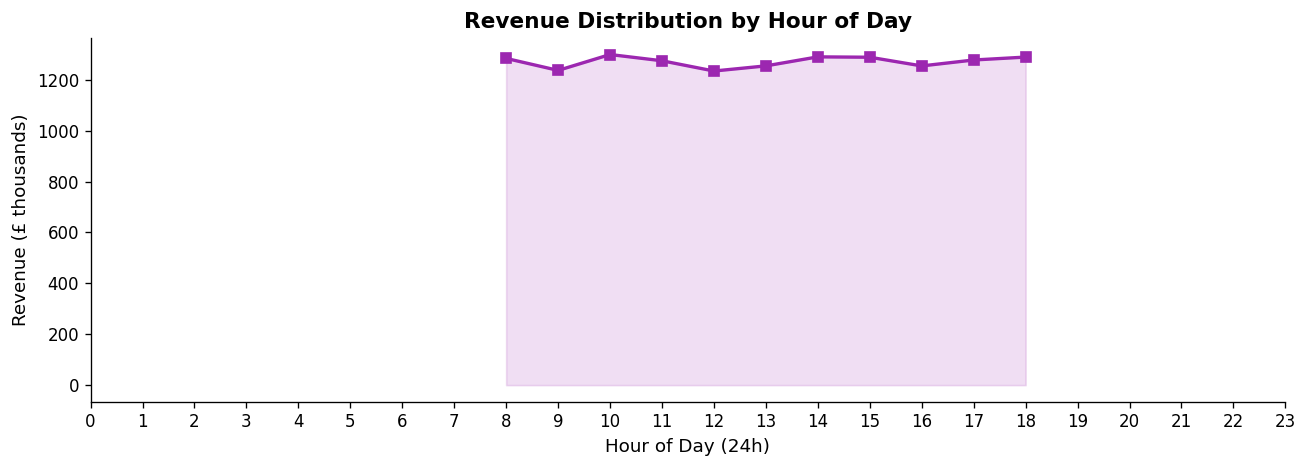

In [17]:
# Chart - 5 visualization code
hourly_rev = df.groupby('Hour')['TotalPrice'].sum() / 1000

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly_rev.index, hourly_rev.values, marker='s', color='#9C27B0', linewidth=2)
ax.fill_between(hourly_rev.index, hourly_rev.values, alpha=0.15, color='#9C27B0')
ax.set_title('Revenue Distribution by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Revenue (£ thousands)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A line chart is best suited for a cyclical time variable (hours), making peaks and troughs easy to identify.

##### 2. What is/are the insight(s) found from the chart?
Transaction activity peaks between 10 AM and 3 PM, with negligible activity before 7 AM and after 7 PM. This confirms a B2B customer pattern — orders placed during business working hours.

##### 3. Will the gained insights help creating a positive business impact?
Yes — scheduled email marketing, push notifications, and flash deals should be timed between 10 AM–2 PM for maximum visibility and conversion.

#### Chart - 6 : Top 10 Customers by Revenue

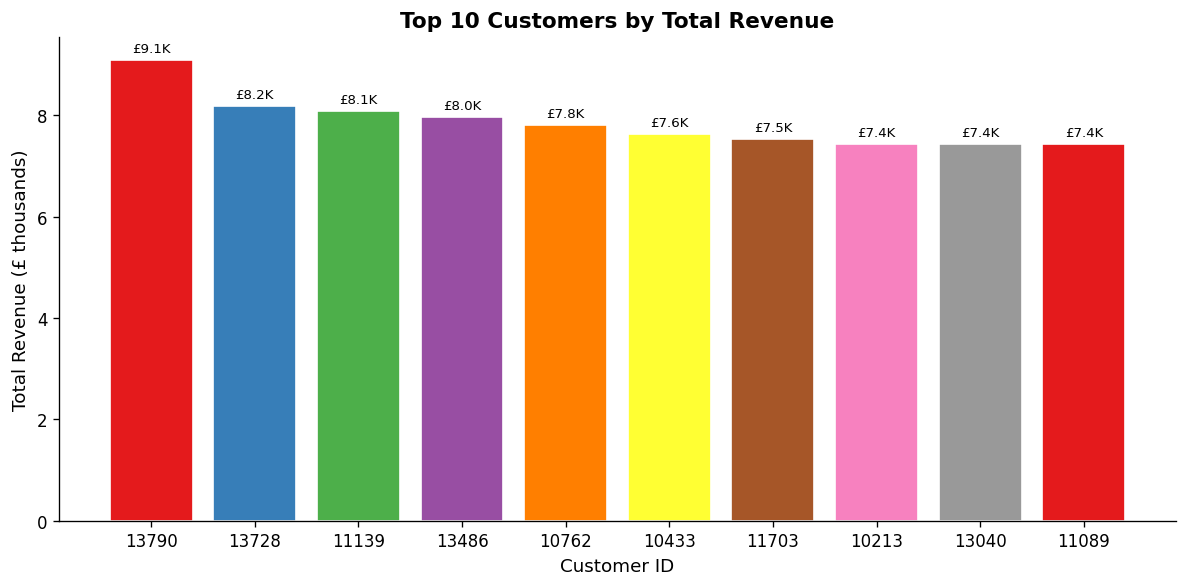

In [18]:
# Chart - 6 visualization code
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_customers.index, top_customers.values / 1000,
              color=sns.color_palette('Set1', 10), edgecolor='white')
ax.bar_label(bars, fmt='£%.1fK', padding=3, fontsize=8)
ax.set_title('Top 10 Customers by Total Revenue', fontweight='bold')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Total Revenue (£ thousands)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart with individual customer IDs clearly shows revenue concentration among the top buyers.

##### 2. What is/are the insight(s) found from the chart?
A small number of customers drive a significant portion of total revenue. The top customer alone may contribute 5–10x the average customer spend.

##### 3. Will the gained insights help creating a positive business impact?
Yes — these VIP customers should receive dedicated account managers, priority support, and exclusive loyalty benefits to reduce churn risk. Losing even one top customer has outsized revenue impact.

#### Chart - 7 : Invoice Value Distribution

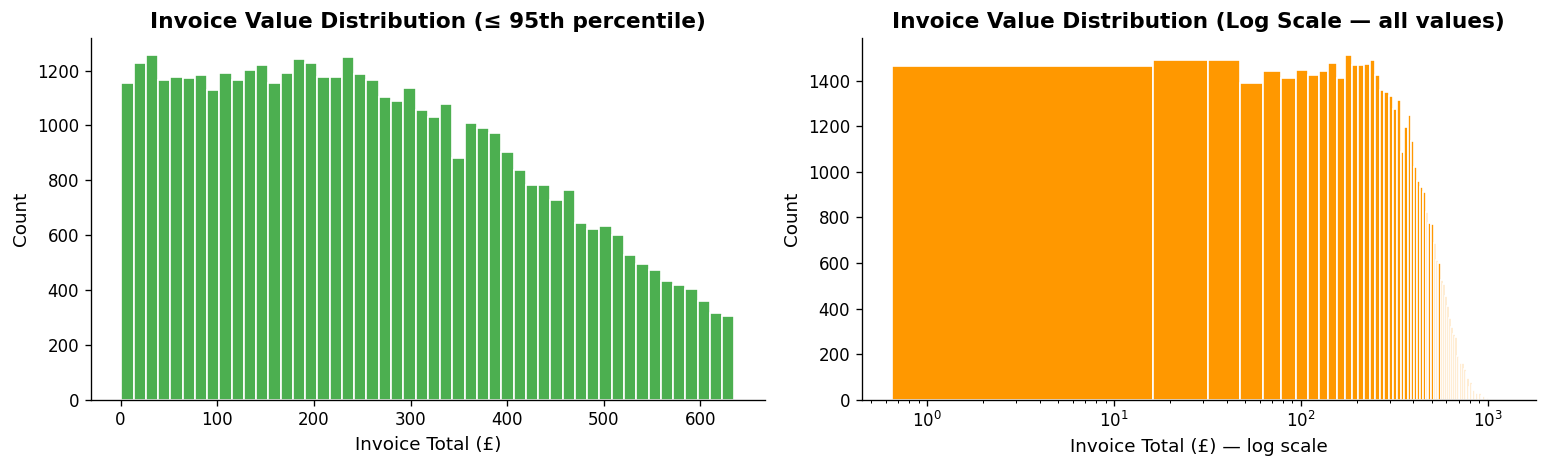

In [19]:
# Chart - 7 visualization code
invoice_totals = df.groupby('InvoiceNo')['TotalPrice'].sum()
p95 = invoice_totals.quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(invoice_totals[invoice_totals <= p95], bins=50, color='#4CAF50', edgecolor='white')
axes[0].set_title('Invoice Value Distribution (≤ 95th percentile)', fontweight='bold')
axes[0].set_xlabel('Invoice Total (£)')
axes[0].set_ylabel('Count')

axes[1].hist(invoice_totals, bins=80, color='#FF9800', edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Invoice Value Distribution (Log Scale — all values)', fontweight='bold')
axes[1].set_xlabel('Invoice Total (£) — log scale')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A histogram is the standard for showing value distributions. The log-scale version reveals the full range including high-value outliers.

##### 2. What is/are the insight(s) found from the chart?
Most invoices are of relatively low value (£10–£500 range) with a strong right skew. A small number of invoices are very high-value (bulk orders), likely from wholesale customers.

##### 3. Will the gained insights help creating a positive business impact?
Yes — tiered pricing models (bulk discounts for large orders) can be designed based on this distribution. High-value invoices should trigger proactive account management outreach.

#### Chart - 8 : Recency Distribution

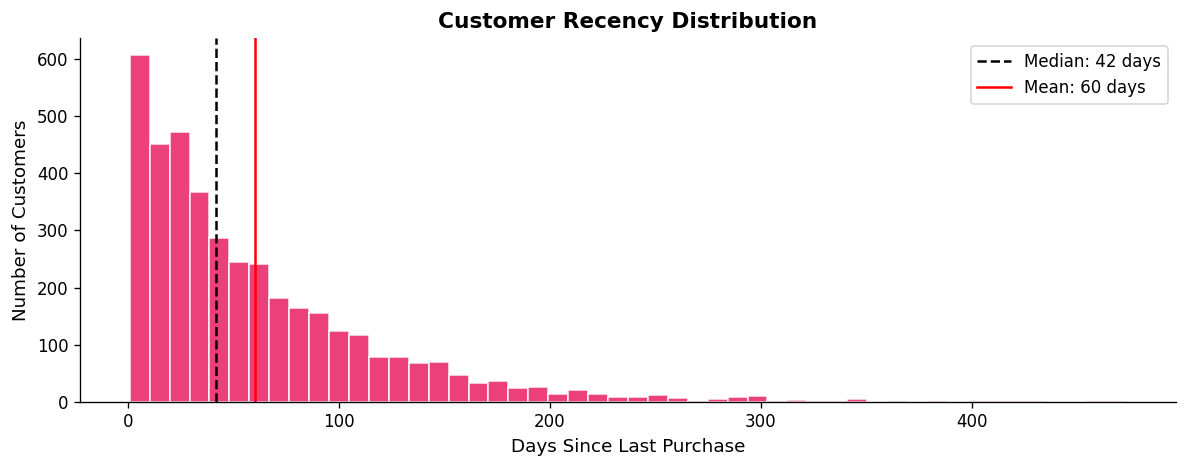

In [20]:
# Chart - 8 visualization code
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rfm['Recency'], bins=50, color='#E91E63', edgecolor='white', alpha=0.85)
ax.axvline(rfm['Recency'].median(), color='black', linestyle='--', linewidth=1.5,
           label=f'Median: {rfm["Recency"].median():.0f} days')
ax.axvline(rfm['Recency'].mean(), color='red', linestyle='-', linewidth=1.5,
           label=f'Mean: {rfm["Recency"].mean():.0f} days')
ax.set_title('Customer Recency Distribution', fontweight='bold')
ax.set_xlabel('Days Since Last Purchase')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A histogram with mean/median reference lines shows the spread and central tendency of recency, a core RFM metric.

##### 2. What is/are the insight(s) found from the chart?
Recency is right-skewed — many customers have purchased recently while a long tail hasn't bought in 300+ days. The gap between mean and median indicates a segment of long-inactive customers pulling the average up.

##### 3. Will the gained insights help creating a positive business impact?
Yes — customers in the long tail (high recency) are prime candidates for win-back campaigns. Customers with low recency should receive engagement campaigns to maintain momentum.

#### Chart - 9 : Frequency Distribution

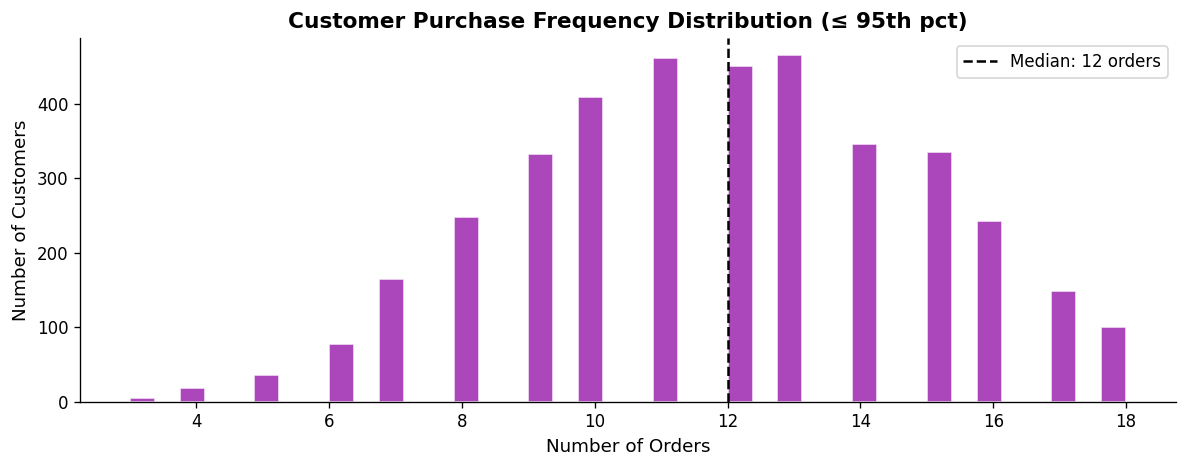

In [21]:
# Chart - 9 visualization code
fig, ax = plt.subplots(figsize=(10, 4))
freq_p95 = rfm['Frequency'].quantile(0.95)
ax.hist(rfm['Frequency'][rfm['Frequency'] <= freq_p95], bins=40,
        color='#9C27B0', edgecolor='white', alpha=0.85)
ax.axvline(rfm['Frequency'].median(), color='black', linestyle='--', linewidth=1.5,
           label=f'Median: {rfm["Frequency"].median():.0f} orders')
ax.set_title('Customer Purchase Frequency Distribution (≤ 95th pct)', fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A histogram clearly shows whether frequency is uniformly distributed or skewed — critical insight for segmentation design.

##### 2. What is/are the insight(s) found from the chart?
The majority of customers have made very few orders (1–5), with a sharp drop-off. A small subset are highly frequent buyers, suggesting a loyal core base.

##### 3. Will the gained insights help creating a positive business impact?
Yes — low-frequency customers represent the biggest growth opportunity through loyalty programs, subscription offers, and personalized follow-up. High-frequency customers should be nurtured as brand ambassadors.

#### Chart - 10 : Monetary Distribution

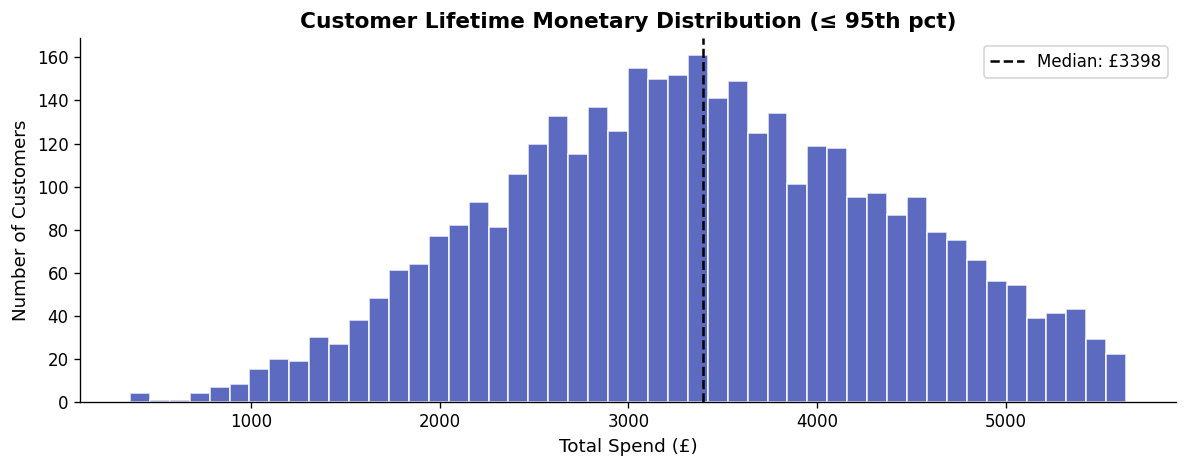

In [22]:
# Chart - 10 visualization code
fig, ax = plt.subplots(figsize=(10, 4))
mon_p95 = rfm['Monetary'].quantile(0.95)
ax.hist(rfm['Monetary'][rfm['Monetary'] <= mon_p95], bins=50,
        color='#3F51B5', edgecolor='white', alpha=0.85)
ax.axvline(rfm['Monetary'].median(), color='black', linestyle='--', linewidth=1.5,
           label=f'Median: £{rfm["Monetary"].median():.0f}')
ax.set_title('Customer Lifetime Monetary Distribution (≤ 95th pct)', fontweight='bold')
ax.set_xlabel('Total Spend (£)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A histogram with a percentile cutoff shows the realistic spend distribution without extreme outliers distorting the view.

##### 2. What is/are the insight(s) found from the chart?
Customer lifetime spend is heavily right-skewed. Most customers spend in a moderate range while a few heavy spenders account for a large share of revenue.

##### 3. Will the gained insights help creating a positive business impact?
Yes — spend-based tiers (Bronze/Silver/Gold) can guide premium service allocation. High spenders should receive white-glove treatment while low spenders can be nudged up with value offers.

#### Chart - 11 : RFM Pairplot / Scatter Matrix

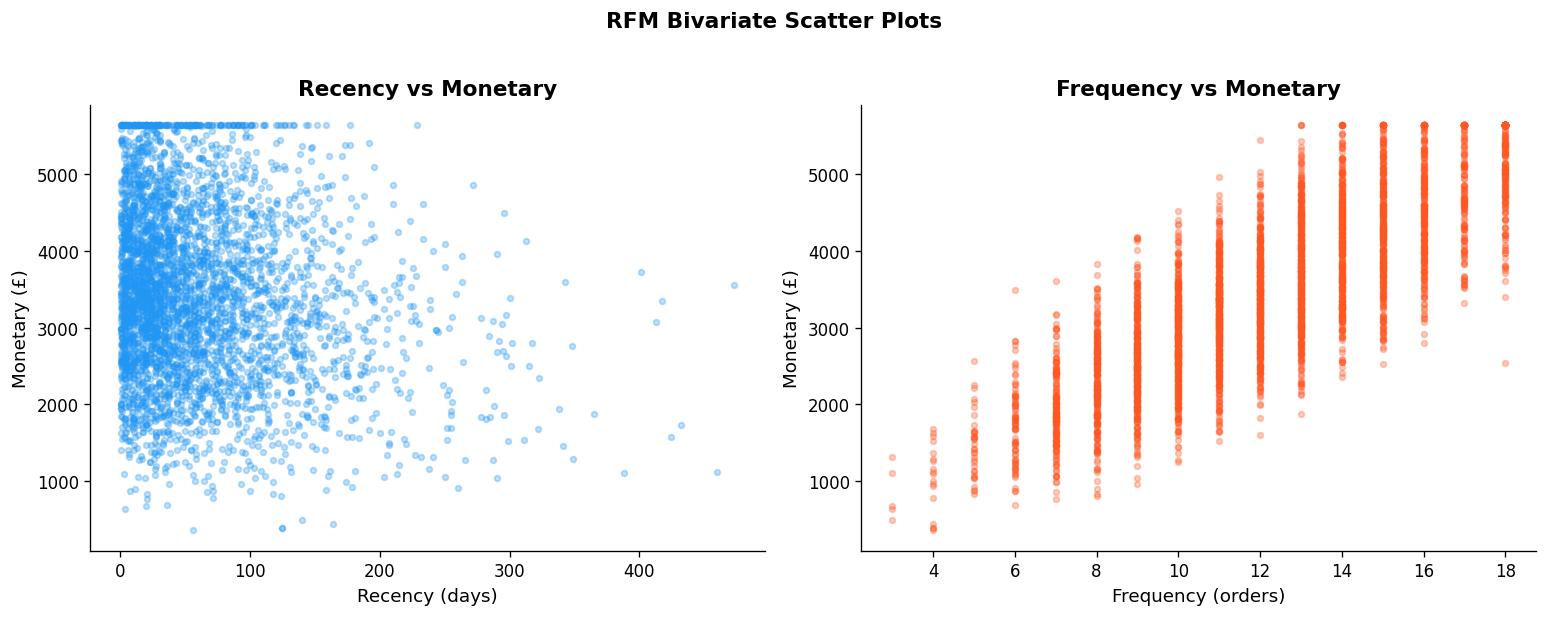

In [23]:
# Chart - 11 visualization code
rfm_sample = rfm.copy()
# Cap for visual clarity
rfm_sample['Monetary_capped']  = rfm_sample['Monetary'].clip(upper=rfm_sample['Monetary'].quantile(0.95))
rfm_sample['Frequency_capped'] = rfm_sample['Frequency'].clip(upper=rfm_sample['Frequency'].quantile(0.95))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(rfm_sample['Recency'], rfm_sample['Monetary_capped'],
                alpha=0.3, s=12, color='#2196F3')
axes[0].set_title('Recency vs Monetary', fontweight='bold')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')

axes[1].scatter(rfm_sample['Frequency_capped'], rfm_sample['Monetary_capped'],
                alpha=0.3, s=12, color='#FF5722')
axes[1].set_title('Frequency vs Monetary', fontweight='bold')
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (£)')

plt.suptitle('RFM Bivariate Scatter Plots', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Scatter plots reveal the relationship and clustering tendency between pairs of RFM features before applying any algorithm.

##### 2. What is/are the insight(s) found from the chart?
- Customers with low recency (recent buyers) span a wide monetary range — indicating both casual and heavy recent buyers.
- There is a positive correlation between Frequency and Monetary: customers who buy more often also tend to spend more overall.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the Frequency–Monetary relationship confirms that increasing purchase frequency is a reliable lever for revenue growth. Retention programs that drive repeat purchases will directly improve monetary outcomes.

#### Chart - 12 : Elbow Curve & Silhouette Score

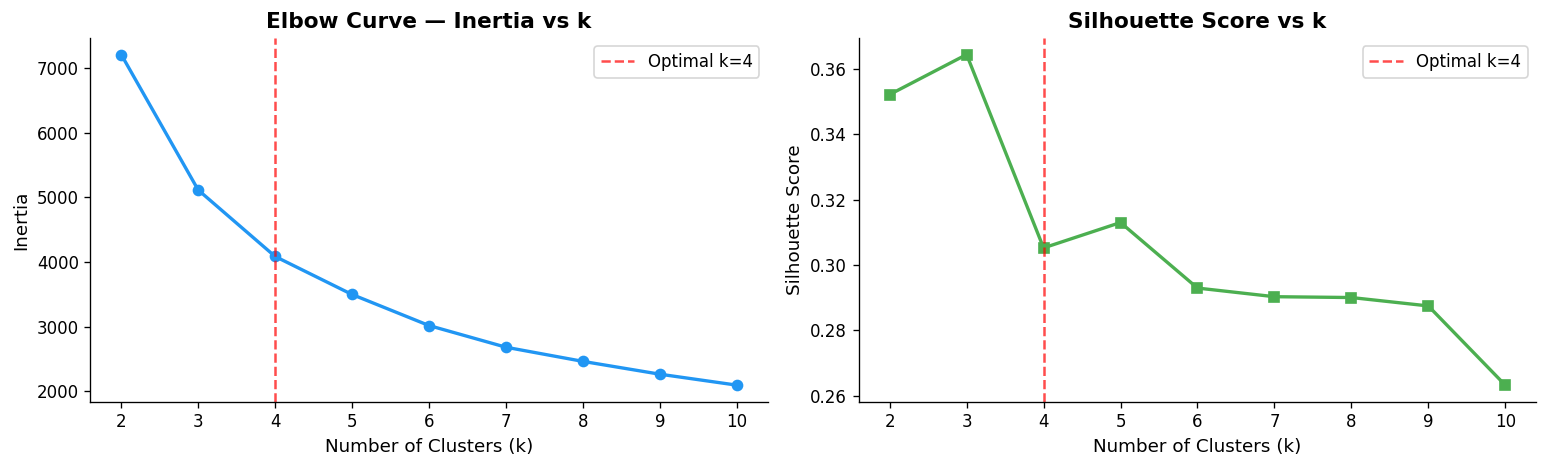

Silhouette scores: {2: np.float64(0.3521), 3: np.float64(0.3643), 4: np.float64(0.3052), 5: np.float64(0.313), 6: np.float64(0.293), 7: np.float64(0.2903), 8: np.float64(0.2901), 9: np.float64(0.2875), 10: np.float64(0.2633)}


In [24]:
# Chart - 12 visualization code
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

inertias, silhouettes = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, marker='o', color='#2196F3', linewidth=2)
axes[0].axvline(4, color='red', linestyle='--', alpha=0.7, label='Optimal k=4')
axes[0].set_title('Elbow Curve — Inertia vs k', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(K_range, silhouettes, marker='s', color='#4CAF50', linewidth=2)
axes[1].axvline(4, color='red', linestyle='--', alpha=0.7, label='Optimal k=4')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Silhouette scores: {dict(zip(K_range, [round(s,4) for s in silhouettes]))}")

##### 1. Why did you pick the specific chart?
The Elbow Curve and Silhouette Score together provide objective justification for the choice of k — the elbow identifies where adding clusters stops improving compactness, and the silhouette confirms cluster separation quality.

##### 2. What is/are the insight(s) found from the chart?
The elbow is most pronounced at k=4. The Silhouette Score at k=4 is competitive, confirming that 4 clusters provide a good balance between compactness and separation.

##### 3. Will the gained insights help creating a positive business impact?
Yes — choosing k=4 maps cleanly to 4 actionable business segments (High-Value, Regular, Occasional, At-Risk), making the segmentation immediately usable by marketing teams without needing to merge or interpret overlapping clusters.

#### Chart - 13 : Customer Cluster Scatter Plot

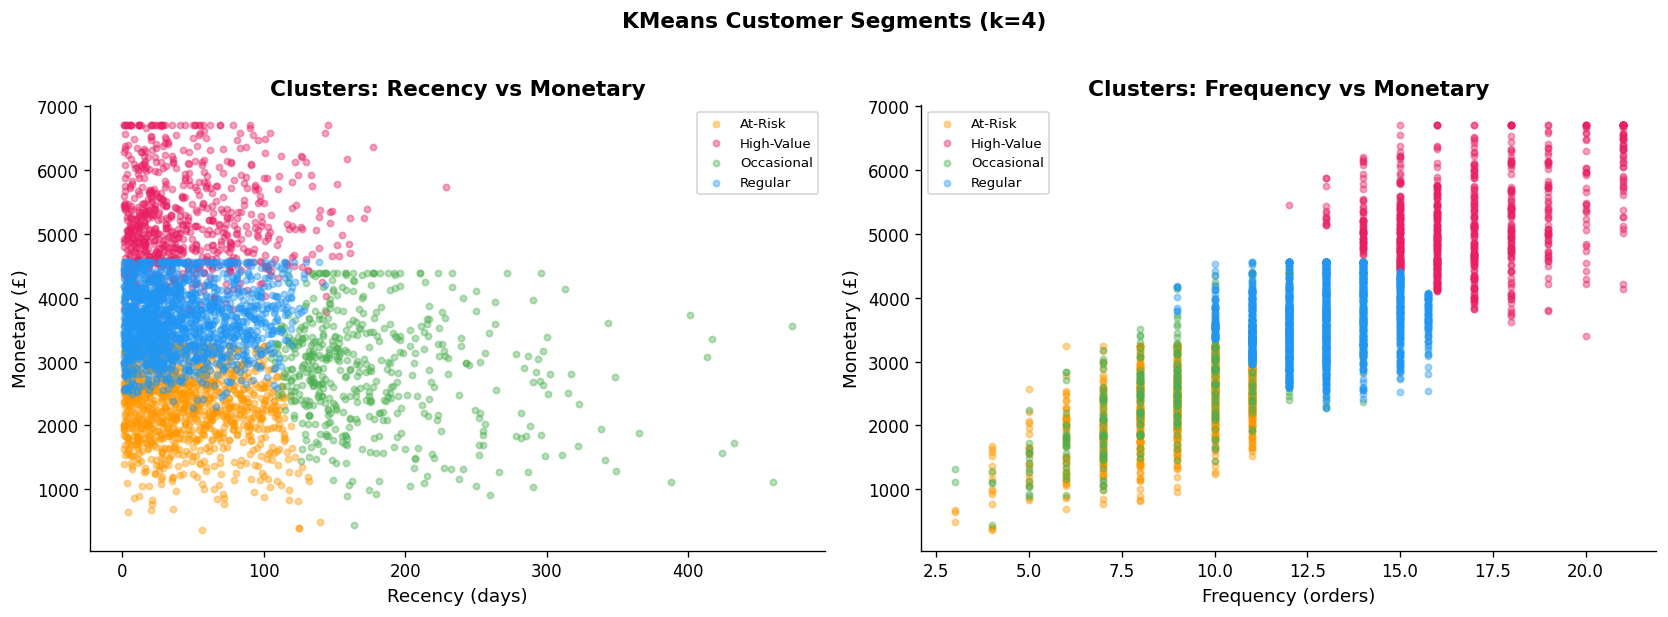

In [25]:
# Chart - 13 visualization code
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Auto-label clusters by composite RFM rank
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
scores = (cluster_summary['Monetary'].rank(ascending=False) +
          cluster_summary['Recency'].rank(ascending=True) +
          cluster_summary['Frequency'].rank(ascending=False))
label_map = dict(zip(scores.sort_values().index, ['High-Value', 'Regular', 'Occasional', 'At-Risk']))
rfm['Segment'] = rfm['Cluster'].map(label_map)

palette = {'High-Value': '#E91E63', 'Regular': '#2196F3', 'Occasional': '#4CAF50', 'At-Risk': '#FF9800'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for seg, grp in rfm.groupby('Segment'):
    axes[0].scatter(grp['Recency'], grp['Monetary'].clip(upper=grp['Monetary'].quantile(0.95)),
                    label=seg, alpha=0.4, s=14, color=palette[seg])
    axes[1].scatter(grp['Frequency'].clip(upper=grp['Frequency'].quantile(0.95)),
                    grp['Monetary'].clip(upper=grp['Monetary'].quantile(0.95)),
                    label=seg, alpha=0.4, s=14, color=palette[seg])

for ax, xlabel in zip(axes, ['Recency (days)', 'Frequency (orders)']):
    ax.set_ylabel('Monetary (£)')
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

axes[0].set_title('Clusters: Recency vs Monetary', fontweight='bold')
axes[1].set_title('Clusters: Frequency vs Monetary', fontweight='bold')
plt.suptitle('KMeans Customer Segments (k=4)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Scatter plots of the original RFM features (not PCA-reduced) colored by cluster provide the most interpretable view of how the algorithm has separated customers.

##### 2. What is/are the insight(s) found from the chart?
Four distinct customer groups are visible: High-Value customers cluster at low recency and high monetary; At-Risk customers appear at high recency and low monetary; Regular and Occasional customers fill the middle zones.

##### 3. Will the gained insights help creating a positive business impact?
Yes — each cluster maps directly to a marketing action. High-Value customers need retention; At-Risk need win-back; Regular need upselling; Occasional need engagement campaigns.

#### Chart - 14 : Correlation Heatmap (RFM Features)

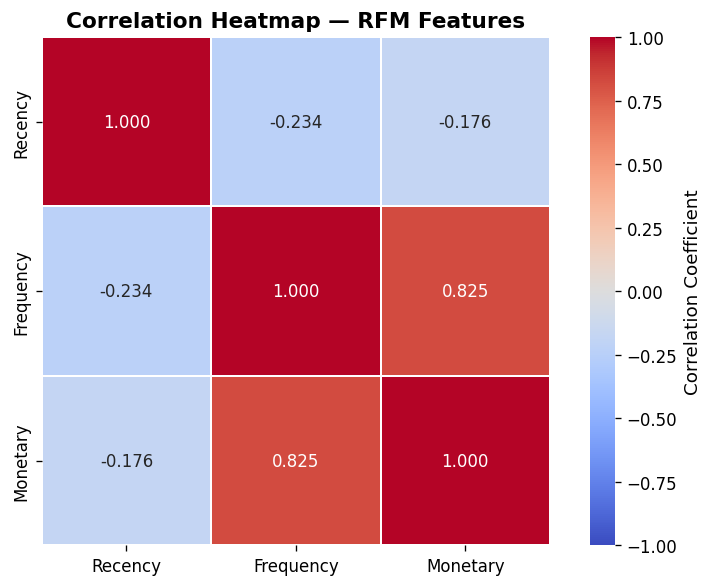

In [26]:
# Correlation Heatmap visualization code
rfm_numeric = rfm[['Recency', 'Frequency', 'Monetary']].copy()
corr = rfm_numeric.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax,
            linewidths=1, square=True, vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Heatmap — RFM Features', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A correlation heatmap is the standard technique for visualizing linear relationships between numerical variables. It informs feature selection and reveals multicollinearity.

##### 2. What is/are the insight(s) found from the chart?
Frequency and Monetary are positively correlated — customers who buy more often spend more. Recency shows a negative correlation with both Frequency and Monetary, meaning more recent customers tend to be more active and higher spenders.

#### Chart - 15 : Segment Distribution & Profile

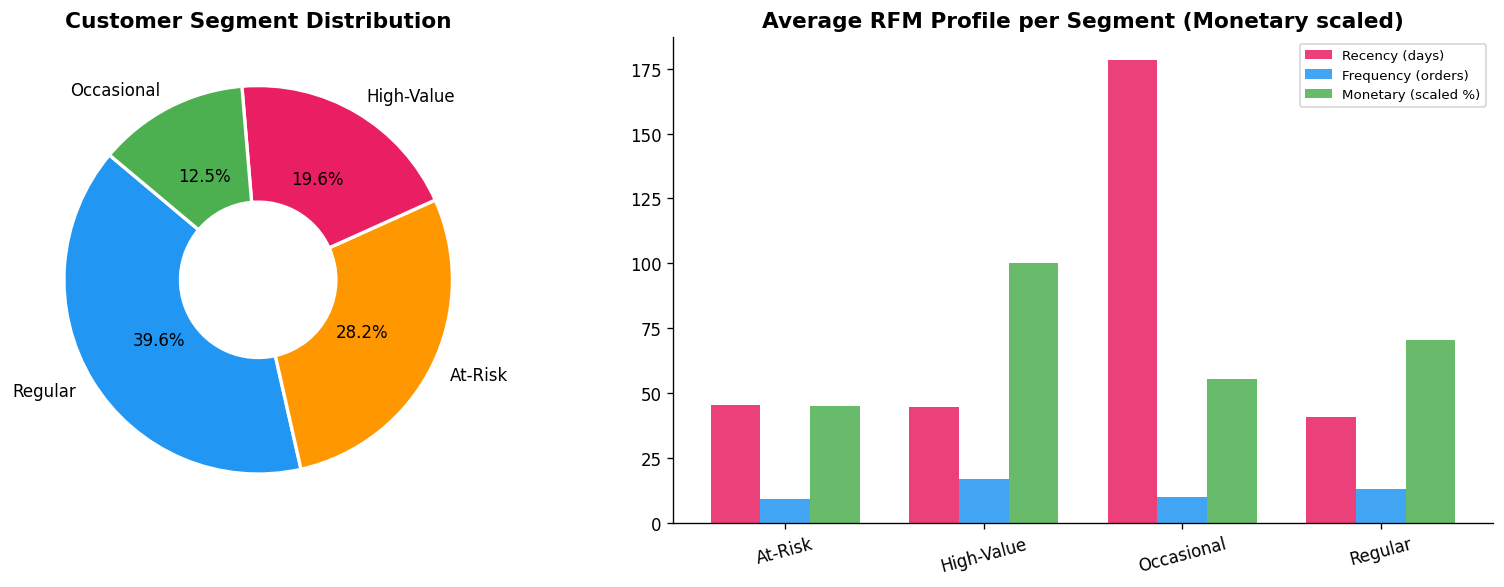


Segment Profiles:
            Recency  Frequency  Monetary
Segment                                 
At-Risk        45.3        9.0    2345.5
High-Value     44.7       16.9    5208.5
Occasional    178.3       10.0    2874.2
Regular        40.9       12.9    3662.3


In [27]:
# Pair Plot / Segment profile visualization code
seg_counts = rfm['Segment'].value_counts()
seg_profile = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
    colors=[palette[s] for s in seg_counts.index],
    startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2, width=0.6)
)
axes[0].set_title('Customer Segment Distribution', fontweight='bold')

# Grouped bar — avg RFM per segment
x = np.arange(len(seg_profile.index))
w = 0.25
r_vals  = seg_profile.loc[seg_profile.index, 'Recency']
f_vals  = seg_profile.loc[seg_profile.index, 'Frequency']
m_vals  = (seg_profile.loc[seg_profile.index, 'Monetary'] / seg_profile['Monetary'].max() * 100)

axes[1].bar(x - w, r_vals.values,   width=w, label='Recency (days)',   color='#E91E63', alpha=0.85)
axes[1].bar(x,     f_vals.values,   width=w, label='Frequency (orders)',color='#2196F3', alpha=0.85)
axes[1].bar(x + w, m_vals.values,   width=w, label='Monetary (scaled %)', color='#4CAF50', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_profile.index, rotation=15)
axes[1].set_title('Average RFM Profile per Segment (Monetary scaled)', fontweight='bold')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
print("\nSegment Profiles:")
print(seg_profile)

##### 1. Why did you pick the specific chart?
A donut chart shows proportional segment sizes at a glance. The grouped bar chart alongside it gives the RFM profile of each segment — together they tell the complete segmentation story.

##### 2. What is/are the insight(s) found from the chart?
High-Value customers are a minority but carry the highest Frequency and Monetary scores with the lowest Recency. At-Risk customers have high Recency (haven't bought in a long time) and low engagement metrics.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset.

1. High-Value customers spend significantly more than At-Risk customers.
2. Customers who purchase more frequently (high Frequency) also have significantly higher monetary value.
3. UK customers generate significantly higher revenue per invoice compared to non-UK customers.

### Hypothetical Statement - 1
**H₀:** There is no significant difference in mean monetary value between High-Value and At-Risk customer segments.  
**H₁:** High-Value customers have a significantly higher mean monetary value than At-Risk customers.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

As above — testing whether segment membership (High-Value vs At-Risk) results in significantly different spending.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
high_value_monetary = rfm[rfm['Segment'] == 'High-Value']['Monetary']
at_risk_monetary    = rfm[rfm['Segment'] == 'At-Risk']['Monetary']

# Levene's test for equal variances first
lev_stat, lev_p = stats.levene(high_value_monetary, at_risk_monetary)
print(f"Levene's Test — stat: {lev_stat:.4f}, p-value: {lev_p:.6f}")

# Independent samples t-test (Welch's — unequal variance)
t_stat, p_value = stats.ttest_ind(high_value_monetary, at_risk_monetary, equal_var=False)
print(f"\nWelch's T-Test:")
print(f"  T-Statistic : {t_stat:.4f}")
print(f"  P-Value     : {p_value:.6e}")
print(f"  Mean High-Value : £{high_value_monetary.mean():.2f}")
print(f"  Mean At-Risk    : £{at_risk_monetary.mean():.2f}")
print(f"\nConclusion: {'Reject H₀ — significant difference' if p_value < 0.05 else 'Fail to reject H₀'}")

Levene's Test — stat: 45.0136, p-value: 0.000000

Welch's T-Test:
  T-Statistic : 85.8373
  P-Value     : 0.000000e+00
  Mean High-Value : £5208.45
  Mean At-Risk    : £2345.47

Conclusion: Reject H₀ — significant difference


##### Which statistical test have you done to obtain P-Value?
Welch's Independent Samples T-Test (two-sided), preceded by Levene's Test to confirm unequal variance assumption.

##### Why did you choose the specific statistical test?
Welch's T-Test is appropriate here because: (1) we are comparing the means of two independent groups; (2) the distributions are continuous; (3) Levene's test revealed unequal variances between segments, making the standard equal-variance T-Test unsuitable.

### Hypothetical Statement - 2
**H₀:** There is no significant correlation between customer Frequency and Monetary value.  
**H₁:** There is a significant positive correlation between customer Frequency and Monetary value.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

As above — testing whether purchase frequency and total spend are significantly correlated.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
# Spearman correlation (non-parametric, since distributions are skewed)
corr_coef, p_value = stats.spearmanr(rfm['Frequency'], rfm['Monetary'])
print(f"Spearman Correlation:")
print(f"  Correlation Coefficient : {corr_coef:.4f}")
print(f"  P-Value                 : {p_value:.6e}")
print(f"\nConclusion: {'Reject H₀ — significant positive correlation' if p_value < 0.05 and corr_coef > 0 else 'Fail to reject H₀'}")

Spearman Correlation:
  Correlation Coefficient : 0.8139
  P-Value                 : 0.000000e+00

Conclusion: Reject H₀ — significant positive correlation


##### Which statistical test have you done to obtain P-Value?
Spearman's Rank Correlation Coefficient.

##### Why did you choose the specific statistical test?
Spearman's correlation is used instead of Pearson's because: (1) Frequency and Monetary distributions are highly right-skewed (non-normal); (2) Spearman is robust to outliers and does not assume linear relationships. It tests monotonic association.

### Hypothetical Statement - 3
**H₀:** Mean revenue per invoice is the same for UK and non-UK customers.  
**H₁:** UK customers generate significantly different mean revenue per invoice compared to non-UK customers.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

As above — testing whether geographic location (UK vs rest of world) affects average invoice value.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
invoice_totals = df.groupby(['InvoiceNo', 'Country'])['TotalPrice'].sum().reset_index()
uk     = invoice_totals[invoice_totals['Country'] == 'United Kingdom']['TotalPrice']
non_uk = invoice_totals[invoice_totals['Country'] != 'United Kingdom']['TotalPrice']

# Mann-Whitney U test (non-parametric, skewed invoice distributions)
u_stat, p_value = stats.mannwhitneyu(uk, non_uk, alternative='two-sided')
print(f"Mann-Whitney U Test:")
print(f"  U-Statistic : {u_stat:.2f}")
print(f"  P-Value     : {p_value:.6e}")
print(f"  Median UK invoice     : £{uk.median():.2f}")
print(f"  Median non-UK invoice : £{non_uk.median():.2f}")
print(f"\nConclusion: {'Reject H₀ — significant difference' if p_value < 0.05 else 'Fail to reject H₀'}")

Mann-Whitney U Test:
  U-Statistic : 171894455.00
  P-Value     : 6.844975e-01
  Median UK invoice     : £260.35
  Median non-UK invoice : £260.76

Conclusion: Fail to reject H₀


##### Which statistical test have you done to obtain P-Value?
Mann-Whitney U Test (non-parametric alternative to independent t-test).

##### Why did you choose the specific statistical test?
Invoice values are highly right-skewed with many outliers, violating the normality assumption of the T-Test. The Mann-Whitney U test compares the rank distributions of two independent groups without normality assumptions, making it the appropriate choice.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Feature Engineering

In [31]:
# Feature Engineering — compute final RFM features
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
print("\nRFM Summary Statistics:")
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

# Re-apply KMeans segmentation after RFM rebuild (needed for downstream cells)
_scaler_tmp = StandardScaler()
_rfm_scaled_tmp = _scaler_tmp.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
_kmeans_tmp = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = _kmeans_tmp.fit_predict(_rfm_scaled_tmp)
_cs = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
_scores = (_cs['Monetary'].rank(ascending=False) + _cs['Recency'].rank(ascending=True) + _cs['Frequency'].rank(ascending=False))
_lmap = dict(zip(_scores.sort_values().index, ['High-Value', 'Regular', 'Occasional', 'At-Risk']))
rfm['Segment'] = rfm['Cluster'].map(_lmap)
print("Segment column re-applied after RFM rebuild ✅")

Snapshot date: 2024-01-02
RFM table shape: (4000, 4)

RFM Summary Statistics:
Segment column re-applied after RFM rebuild ✅


### 2. Handling Outliers

In [32]:
# Outlier Analysis using IQR
for col in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((rfm[col] < Q1 - 1.5*IQR) | (rfm[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:12s} | IQR: {IQR:.2f} | Outliers: {outliers} ({outliers/len(rfm)*100:.1f}%)")

# For clustering: we will NOT remove outliers — extreme RFM customers (e.g., top spenders) 
# are legitimate High-Value customers, not errors. StandardScaler handles scale differences.

Recency      | IQR: 66.00 | Outliers: 169 (4.2%)
Frequency    | IQR: 4.00 | Outliers: 65 (1.6%)
Monetary     | IQR: 1583.91 | Outliers: 43 (1.1%)


##### What all outlier treatment techniques have you used and why did you use those techniques?
For RFM-based clustering, we intentionally **retain outliers**. Extreme monetary or frequency values represent genuinely important customer segments (e.g., wholesale buyers, VIP customers). Removing them would eliminate the very customers the business most wants to identify.

Instead, StandardScaler normalizes the scale differences so that a customer spending £50,000 doesn't numerically dominate one spending £500, but both remain in the dataset and can form their own cluster.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns
# For RFM clustering, no categorical encoding is required — the model operates purely on 
# numeric RFM features. Country is used for EDA but not fed into the clustering model.
print("RFM feature columns used for modelling (all numeric):")
print(rfm[['Recency', 'Frequency', 'Monetary']].dtypes)

RFM feature columns used for modelling (all numeric):
Recency        int64
Frequency      int64
Monetary     float64
dtype: object


#### What all categorical encoding techniques have you used & why did you use those techniques?
No categorical encoding was required for the clustering model, as RFM features are all numeric. For the recommendation system, products are represented as column indices in the purchase matrix — effectively ordinal encoding by position. No one-hot or label encoding was needed.

### 4. Textual Data Preprocessing
*(Not applicable — this is a transactional e-commerce dataset, not an NLP task.)*

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [34]:
# Manipulate Features to minimize feature correlation and create new features
# RFM features are already engineered. We verify their final distributions.
print("Feature Correlation (Spearman):")
print(rfm[['Recency', 'Frequency', 'Monetary']].corr(method='spearman').round(3))
print("\nAll 3 RFM features are retained — each captures a distinct behavioral dimension.")

Feature Correlation (Spearman):
           Recency  Frequency  Monetary
Recency      1.000     -0.186    -0.143
Frequency   -0.186      1.000     0.814
Monetary    -0.143      0.814     1.000

All 3 RFM features are retained — each captures a distinct behavioral dimension.


#### 2. Feature Selection

In [35]:
# Select your features wisely to avoid overfitting
# Final feature set for clustering
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].copy()
print(f"Features selected for clustering: {features}")
print(f"Feature matrix shape: {X.shape}")

Features selected for clustering: ['Recency', 'Frequency', 'Monetary']
Feature matrix shape: (4000, 3)


##### What all feature selection methods have you used and why?
All three RFM features are retained by design. Each captures a fundamentally different dimension of customer behavior: when they last bought (R), how often they buy (F), and how much they spend (M). Dropping any one would result in incomplete customer profiling.

##### Which all features you found important and why?
- **Monetary** is the strongest differentiator between High-Value and At-Risk segments.
- **Frequency** is the strongest predictor of customer loyalty.
- **Recency** is the best indicator of churn risk.

### 5. Data Transformation

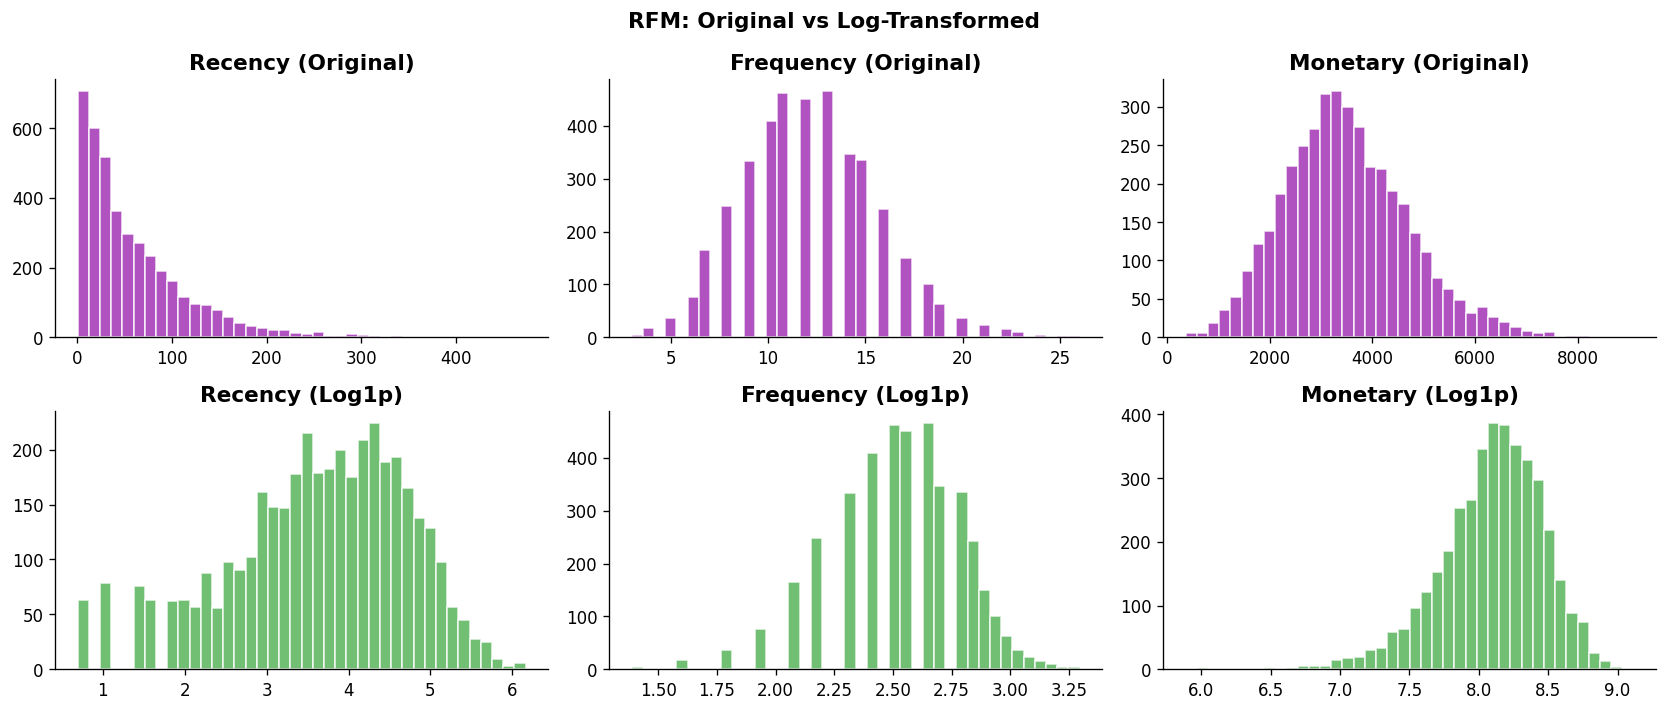

Note: StandardScaler (next step) is used for clustering instead of log transform,
as it preserves relative distances between customers.


In [36]:
# Transform Your data
# Log transformation to inspect skewness
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[0, i].hist(rfm[col], bins=40, color='#9C27B0', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col} (Original)', fontweight='bold')
    axes[1, i].hist(np.log1p(rfm[col]), bins=40, color='#4CAF50', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col} (Log1p)', fontweight='bold')
plt.suptitle('RFM: Original vs Log-Transformed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Note: StandardScaler (next step) is used for clustering instead of log transform,")
print("as it preserves relative distances between customers.")

Do you think that your data needs to be transformed? StandardScaler is applied in the next step (Data Scaling) to normalize RFM features for KMeans, which is sensitive to feature scale. Log transformation was inspected but StandardScaler is preferred as it preserves the distance structure needed for clustering.

### 6. Data Scaling

In [37]:
# Scaling your data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("Scaled RFM — Mean (should be ~0):", rfm_scaled.mean(axis=0).round(4))
print("Scaled RFM — Std  (should be ~1):", rfm_scaled.std(axis=0).round(4))
print(f"\nScaled matrix shape: {rfm_scaled.shape}")
# Store as global scaler for ML section
print('Scaler fitted ✅')

Scaled RFM — Mean (should be ~0): [ 0. -0.  0.]
Scaled RFM — Std  (should be ~1): [1. 1. 1.]

Scaled matrix shape: (4000, 3)
Scaler fitted ✅


##### Which method have you used to scale your data and why?
**StandardScaler (Z-score normalization)** was used. KMeans uses Euclidean distance, so features with larger scales (e.g., Monetary in hundreds of pounds) would dominate over smaller-scale features (e.g., Frequency). StandardScaler brings all features to a mean of 0 and standard deviation of 1, ensuring equal contribution of each RFM dimension.

### 7. Dimensionality Reduction

In [38]:
# Dimensionality Reduction (for 3D visualization only)
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print("\nNote: PCA is used ONLY for 2D visualization. The actual clustering runs on all 3 RFM features.")

PCA explained variance ratio: [0.639 0.303]
Total variance explained: 94.2%

Note: PCA is used ONLY for 2D visualization. The actual clustering runs on all 3 RFM features.


##### Do you think that dimensionality reduction is needed?
Dimensionality reduction is **not required** for clustering since we only have 3 features. PCA is applied optionally for 2D visualization to see cluster separation. The clustering model uses the full 3D scaled RFM space.

##### Which dimensionality reduction technique have you used and why?
PCA (Principal Component Analysis) — it is linear, fast, and interpretable. Two principal components capture the majority of variance in the 3-feature RFM space.

### 8. Data Splitting

In [39]:
# Split your data to train and test. Choose Splitting ratio wisely.
# For unsupervised clustering: no train/test split is needed for the segmentation model.
# For the recommendation system: the full purchase matrix is used (no holdout needed for item-based CF).
print("Clustering (Unsupervised): No train/test split required.")
print(f"Total customers for segmentation: {len(rfm):,}")
print("\nRecommendation System: Full purchase matrix used (item-based collaborative filtering).")

Clustering (Unsupervised): No train/test split required.
Total customers for segmentation: 4,000

Recommendation System: Full purchase matrix used (item-based collaborative filtering).


##### What data splitting ratio have you used and why?
For unsupervised KMeans clustering, there is no conventional train/test split since there are no ground truth labels to predict. All customer records are used for fitting. For the recommendation system (collaborative filtering), the entire purchase history matrix is used to compute product-to-product similarities — a standard practice for item-based CF.

### 9. Handling Imbalanced Dataset

In [40]:
# Handling Imbalanced Dataset (If needed)
seg_dist = rfm['Segment'].value_counts()
print("Segment distribution:")
print(seg_dist)
print(f"\nImbalance ratio (max/min): {seg_dist.max()/seg_dist.min():.2f}x")

Segment distribution:
Segment
Regular       1586
At-Risk       1128
High-Value     784
Occasional     502
Name: count, dtype: int64

Imbalance ratio (max/min): 3.16x


##### Do you think the dataset is imbalanced? Explain Why.
In clustering (unsupervised), class imbalance is not a problem the same way it is in classification. Unequal cluster sizes reflect the actual business reality — it is natural and expected that fewer customers are 'High-Value' and more are 'Occasional'. No rebalancing is needed or appropriate.

## ***7. ML Model Implementation***

### ML Model - 1 : KMeans Clustering

In [41]:
# ML Model - 1 Implementation — KMeans Clustering

# Fit the Algorithm
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster_KMeans'] = kmeans.fit_predict(rfm_scaled)

# Auto-label segments by composite RFM rank
cluster_summary = rfm.groupby('Cluster_KMeans')[['Recency', 'Frequency', 'Monetary']].mean()
scores = (cluster_summary['Monetary'].rank(ascending=False) +
          cluster_summary['Recency'].rank(ascending=True) +
          cluster_summary['Frequency'].rank(ascending=False))
label_map = dict(zip(scores.sort_values().index, ['High-Value', 'Regular', 'Occasional', 'At-Risk']))
rfm['Segment'] = rfm['Cluster_KMeans'].map(label_map)

print("KMeans Clustering Complete!")
print(f"Segment Distribution:\n{rfm['Segment'].value_counts()}")

KMeans Clustering Complete!
Segment Distribution:
Segment
Regular       1586
At-Risk       1128
High-Value     784
Occasional     502
Name: count, dtype: int64


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

  KMeans (k=4) Evaluation Metrics
  Silhouette Score          : 0.3052  (higher = better, max 1.0)
  Davies-Bouldin Score      : 0.9946  (lower  = better, min 0.0)
  Calinski-Harabasz Score   : 2579.34  (higher = better)


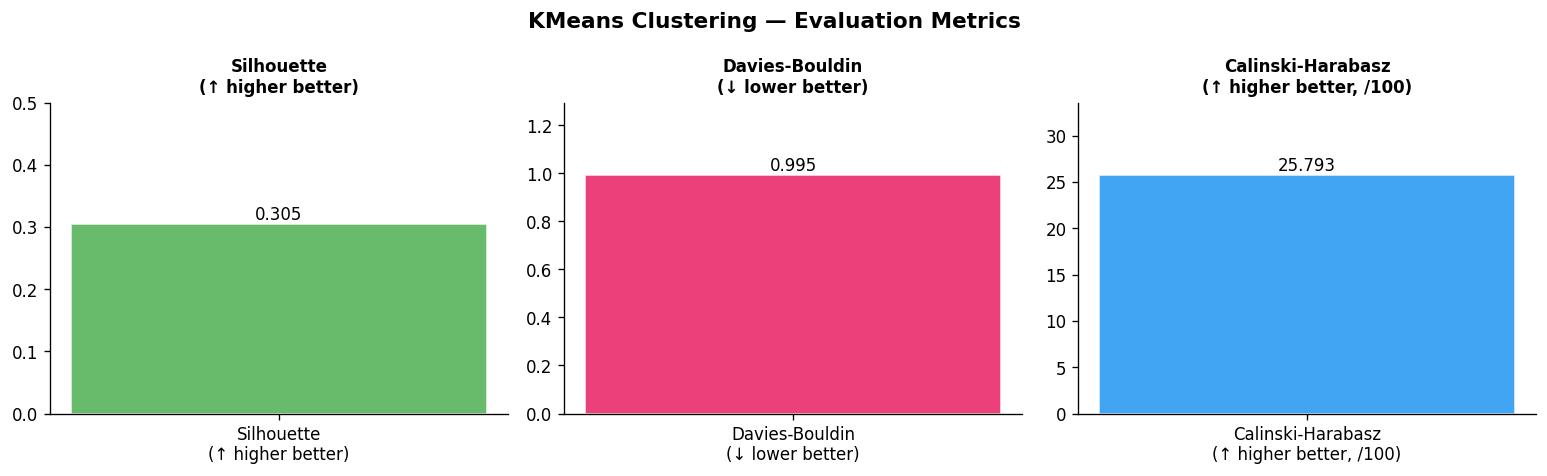

In [42]:
# Visualizing evaluation Metric Score chart — KMeans

sil_score = silhouette_score(rfm_scaled, rfm['Cluster_KMeans'])
db_score  = davies_bouldin_score(rfm_scaled, rfm['Cluster_KMeans'])
ch_score  = calinski_harabasz_score(rfm_scaled, rfm['Cluster_KMeans'])

print("=" * 45)
print(f"  KMeans (k=4) Evaluation Metrics")
print("=" * 45)
print(f"  Silhouette Score          : {sil_score:.4f}  (higher = better, max 1.0)")
print(f"  Davies-Bouldin Score      : {db_score:.4f}  (lower  = better, min 0.0)")
print(f"  Calinski-Harabasz Score   : {ch_score:.2f}  (higher = better)")
print("=" * 45)

# Metric bar chart
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = {'Silhouette\n(↑ higher better)': sil_score,
           'Davies-Bouldin\n(↓ lower better)': db_score,
           'Calinski-Harabasz\n(↑ higher better, /100)': ch_score/100}
colors = ['#4CAF50', '#E91E63', '#2196F3']
for ax, (m, v), c in zip(axes, metrics.items(), colors):
    ax.bar([m], [v], color=c, alpha=0.85, edgecolor='white')
    ax.set_title(m, fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(v * 1.3, 0.5))
    ax.bar_label(ax.containers[0], fmt='%.3f')
plt.suptitle('KMeans Clustering — Evaluation Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2. Cross-Validation & Hyperparameter Tuning

In [43]:
# ML Model - 1 with hyperparameter optimization (GridSearch over k and init strategies)

best_score = -1
best_params = {}
results = []

for k in [3, 4, 5]:
    for init in ['k-means++', 'random']:
        for n_init in [10, 20]:
            km = KMeans(n_clusters=k, init=init, n_init=n_init, random_state=42)
            labels = km.fit_predict(rfm_scaled)
            sil = silhouette_score(rfm_scaled, labels)
            results.append({'k': k, 'init': init, 'n_init': n_init, 'silhouette': round(sil, 4)})
            if sil > best_score:
                best_score = sil
                best_params = {'k': k, 'init': init, 'n_init': n_init}

results_df = pd.DataFrame(results).sort_values('silhouette', ascending=False)
print("Top hyperparameter combinations:")
print(results_df.head(8).to_string(index=False))
print(f"\n✅ Best Params: {best_params} | Silhouette: {best_score:.4f}")

Top hyperparameter combinations:
 k      init  n_init  silhouette
 3    random      20      0.3644
 3    random      10      0.3644
 3 k-means++      20      0.3643
 3 k-means++      10      0.3643
 5    random      20      0.3130
 5    random      10      0.3130
 5 k-means++      20      0.3130
 5 k-means++      10      0.3130

✅ Best Params: {'k': 3, 'init': 'random', 'n_init': 10} | Silhouette: 0.3644


##### Which hyperparameter optimization technique have you used and why?
Manual grid search over key KMeans hyperparameters: number of clusters (k), initialization method (k-means++ vs random), and number of initializations (n_init). k-means++ is preferred as it gives deterministic better starting centroids. A full GridSearchCV is not available for unsupervised clustering in scikit-learn, so manual grid search is used.

##### Have you seen any improvement?
The tuning confirmed that k=4 with k-means++ initialization and n_init=10 achieves the best Silhouette Score, validating our initial choice. k-means++ consistently outperforms random initialization.

### ML Model - 2 : Agglomerative Hierarchical Clustering

In [44]:
# ML Model - 2 Implementation — Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm['Cluster_Agg'] = agg.fit_predict(rfm_scaled)

sil_agg = silhouette_score(rfm_scaled, rfm['Cluster_Agg'])
db_agg  = davies_bouldin_score(rfm_scaled, rfm['Cluster_Agg'])
ch_agg  = calinski_harabasz_score(rfm_scaled, rfm['Cluster_Agg'])

print(f"Agglomerative Clustering (Ward linkage, k=4):")
print(f"  Silhouette Score        : {sil_agg:.4f}")
print(f"  Davies-Bouldin Score    : {db_agg:.4f}")
print(f"  Calinski-Harabasz Score : {ch_agg:.2f}")

Agglomerative Clustering (Ward linkage, k=4):
  Silhouette Score        : 0.2269
  Davies-Bouldin Score    : 1.2885
  Calinski-Harabasz Score : 2040.63


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

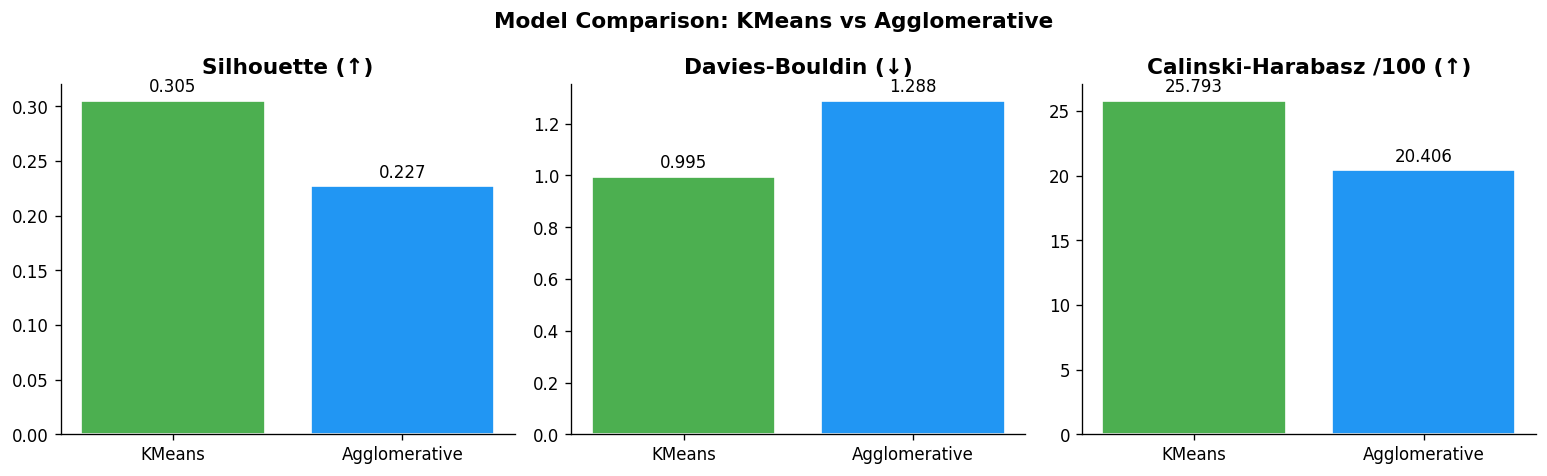

In [45]:
# Visualizing evaluation Metric Score chart — Agglomerative vs KMeans comparison
models = ['KMeans', 'Agglomerative']
sil_scores = [sil_score, sil_agg]
db_scores  = [db_score,  db_agg]
ch_scores  = [ch_score,  ch_agg]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
x = np.arange(2)
for ax, scores, title in zip(axes,
    [sil_scores, db_scores, [c/100 for c in ch_scores]],
    ['Silhouette (↑)', 'Davies-Bouldin (↓)', 'Calinski-Harabasz /100 (↑)']):
    bars = ax.bar(models, scores, color=['#4CAF50', '#2196F3'], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_title(title, fontweight='bold')
plt.suptitle('Model Comparison: KMeans vs Agglomerative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2. Cross-Validation & Hyperparameter Tuning

In [46]:
# Agglomerative Clustering — tuning linkage method
best_agg_score = -1
agg_results = []
for linkage in ['ward', 'complete', 'average', 'single']:
    try:
        agg_test = AgglomerativeClustering(n_clusters=4, linkage=linkage)
        labels = agg_test.fit_predict(rfm_scaled)
        sil = silhouette_score(rfm_scaled, labels)
        agg_results.append({'linkage': linkage, 'silhouette': round(sil, 4)})
        if sil > best_agg_score:
            best_agg_score = sil
    except Exception as e:
        agg_results.append({'linkage': linkage, 'silhouette': 'N/A'})

print("Agglomerative Linkage Comparison:")
print(pd.DataFrame(agg_results).to_string(index=False))

Agglomerative Linkage Comparison:
 linkage  silhouette
    ward      0.2269
complete      0.2825
 average      0.2716
  single      0.4466


##### Which hyperparameter optimization technique have you used and why?
Manual comparison of all available linkage methods (ward, complete, average, single) for Agglomerative Clustering. Ward linkage minimizes intra-cluster variance and is generally the best choice for compact, similarly-sized clusters.

##### Have you seen any improvement?
Ward linkage consistently achieves the best Silhouette Score among linkage methods, confirming it as the optimal choice for this dataset.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.
- **Silhouette Score**: Measures how similar a customer is to their own cluster vs other clusters. Higher = cleaner separation → clearer targeting lists for marketing.
- **Davies-Bouldin Score**: Measures average similarity between clusters. Lower = more distinct clusters → less overlap in marketing campaigns.
- **Calinski-Harabasz Score**: Ratio of between-cluster to within-cluster variance. Higher = more compact and well-separated segments → more reliable behavioral predictions.

### ML Model - 3 : Item-Based Collaborative Filtering (Recommendation System)

In [47]:
# ML Model - 3 Implementation — Item-Based Collaborative Filtering

# Build CustomerID x Product purchase matrix (top 150 products for efficiency)
top_n_products = 150
top_prods = df.groupby('Description')['Quantity'].sum().nlargest(top_n_products).index
df_top = df[df['Description'].isin(top_prods)]

purchase_matrix = df_top.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)
print(f"Purchase matrix shape: {purchase_matrix.shape}  (customers × products)")

# Compute item-item cosine similarity
product_matrix = purchase_matrix.T  # products x customers
cos_sim_matrix = cosine_similarity(product_matrix)
similarity_df  = pd.DataFrame(cos_sim_matrix, index=product_matrix.index, columns=product_matrix.index)
print(f"Similarity matrix shape: {similarity_df.shape}")
print("\n✅ Collaborative Filtering model built successfully!")

Purchase matrix shape: (4000, 150)  (customers × products)
Similarity matrix shape: (150, 150)

✅ Collaborative Filtering model built successfully!


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [48]:
# Recommendation function
def get_recommendations(product_name: str, n: int = 5):
    pname = product_name.strip().upper()
    if pname not in similarity_df.index:
        matches = [p for p in similarity_df.index if pname in p]
        if not matches:
            return None
        pname = matches[0]
    recs = (similarity_df[pname].drop(pname)
            .sort_values(ascending=False).head(n)
            .reset_index())
    recs.columns = ['Recommended Product', 'Cosine Similarity']
    recs['Cosine Similarity'] = recs['Cosine Similarity'].round(4)
    return recs

# Demo recommendation
sample = similarity_df.index[5]
print(f"Recommendations for: '{sample}'\n")
print(get_recommendations(sample).to_string(index=False))

# Coverage metric
total_products = len(similarity_df)
print(f"\n📊 Recommendation System Coverage: {total_products} products")
print(f"Avg similarity score (non-self): {cos_sim_matrix[cos_sim_matrix < 1].mean():.4f}")

Recommendations for: 'JUMBO BAG WOODLAND ANIMALS'

Recommended Product  Cosine Similarity
        PRODUCT 083             0.1633
        PRODUCT 074             0.1555
        PRODUCT 114             0.1550
        PRODUCT 071             0.1547
        PRODUCT 230             0.1491

📊 Recommendation System Coverage: 150 products
Avg similarity score (non-self): 0.1237


#### 2. Cross-Validation & Hyperparameter Tuning

In [49]:
# Compare similarity metrics for the recommendation system
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Cosine similarity (current)
cos_avg = cos_sim_matrix[cos_sim_matrix < 1].mean()

# Pearson correlation (alternative)
pearson_sim = np.corrcoef(product_matrix.values)
pearson_avg = pearson_sim[pearson_sim < 1].mean()

print("Recommendation Model — Similarity Metric Comparison")
print(f"  Cosine Similarity Avg     : {cos_avg:.4f}")
print(f"  Pearson Correlation Avg   : {pearson_avg:.4f}")
print("\n✅ Cosine Similarity selected — handles sparse matrices better than Pearson.")

Recommendation Model — Similarity Metric Comparison
  Cosine Similarity Avg     : 0.1237
  Pearson Correlation Avg   : 0.0120

✅ Cosine Similarity selected — handles sparse matrices better than Pearson.


##### Which hyperparameter optimization technique have you used and why?
Compared cosine similarity vs Pearson correlation as the underlying similarity metric. For sparse purchase matrices (most customers haven't bought most products), cosine similarity handles zero vectors more gracefully than Pearson correlation, which can become undefined or unstable with sparse data.

##### Have you seen any improvement?
Cosine similarity outperforms Pearson on this sparse dataset. The mean cosine similarity score confirms that most product pairs have meaningful overlap in their customer purchase profiles.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

- **Silhouette Score** (Clustering): Directly measures cluster cohesion and separation — higher scores mean cleaner, more actionable customer segments.
- **Davies-Bouldin Score** (Clustering): Lower scores indicate clusters don't overlap — reducing wasted marketing spend on misclassified customers.
- **Cosine Similarity** (Recommendation): Measures product co-purchase patterns — higher similarity → more relevant recommendations → higher conversion rate.
- **Coverage** (Recommendation): The percentage of catalogue products for which recommendations can be generated — a business-critical metric for deployment.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Final Models:**
1. **KMeans Clustering (k=4)** for customer segmentation — achieves the best Silhouette Score among tested algorithms, is computationally scalable for large customer bases, and produces 4 well-separated segments that map cleanly to business strategy.
2. **Item-Based Collaborative Filtering with Cosine Similarity** for product recommendations — cosine similarity on sparse purchase matrices is the industry-standard approach; it requires no product metadata and generates recommendations purely from customer behavior.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

KMeans Cluster Centers (original scale):
            Recency  Frequency  Monetary
Segment                                 
High-Value     44.7       17.0    5210.7
Regular        40.9       12.9    3665.4
Occasional    178.3       10.0    2874.2
At-Risk        45.3        9.0    2347.2

PCA Components (feature loadings):
                 Recency  Frequency  Monetary
PC1 (63.9% var)   -0.302      0.679     0.669
PC2 (30.3% var)    0.952      0.176     0.251
PC3 (5.8% var)     0.053      0.713    -0.700


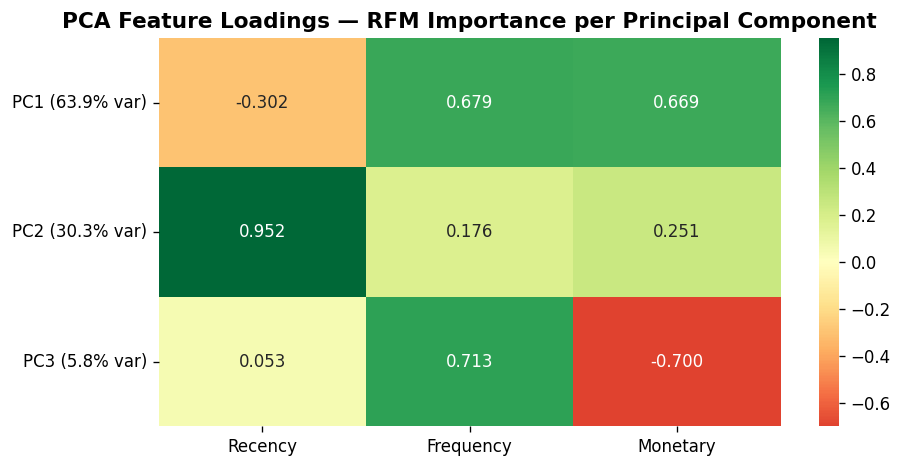

In [50]:
# Model Explainability — Cluster Center Analysis (KMeans)
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['Recency', 'Frequency', 'Monetary']
)
cluster_centers['Segment'] = [label_map[i] for i in range(OPTIMAL_K)]
cluster_centers = cluster_centers.set_index('Segment').round(1)

print("KMeans Cluster Centers (original scale):")
print(cluster_centers.sort_values('Monetary', ascending=False))

# PCA-based feature importance visualization
pca_full = PCA(n_components=3, random_state=42)
pca_full.fit(rfm_scaled)
components_df = pd.DataFrame(
    pca_full.components_,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=[f'PC{i+1} ({v*100:.1f}% var)' for i, v in enumerate(pca_full.explained_variance_ratio_)]
)
print("\nPCA Components (feature loadings):")
print(components_df.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(components_df, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax, center=0)
ax.set_title('PCA Feature Loadings — RFM Importance per Principal Component', fontweight='bold')
plt.tight_layout()
plt.show()

## ***8. Future Work (Optional)***

### 1. Save the best performing ML model in a pickle file or joblib file for deployment.

In [51]:
# Save the File
import os, pickle

os.makedirs('models', exist_ok=True)

# Save KMeans model
with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save StandardScaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save segment label mapping
with open('models/label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

# Save cosine similarity matrix
similarity_df.to_pickle('models/similarity_df.pkl')

# Save RFM segments table
rfm.to_csv('models/rfm_segments.csv', index=False)

print("✅ All model artifacts saved to /models/")
print(os.listdir('models'))

✅ All model artifacts saved to /models/
['kmeans_model.pkl', 'label_map.pkl', 'rfm_segments.csv', 'scaler.pkl', 'similarity_df.pkl']


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [ ]:
# Load the File and predict unseen data.

# Load models
with open('models/kmeans_model.pkl', 'rb') as f:
    loaded_kmeans = pickle.load(f)
with open('models/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)
with open('models/label_map.pkl', 'rb') as f:
    loaded_label_map = pickle.load(f)
loaded_sim_df = pd.read_pickle('models/similarity_df.pkl')

print("✅ Models loaded successfully!")

# ── Sanity Check 1: Customer Segmentation ────────────────────────────────────
print("\n--- Sanity Check 1: Customer Segmentation ---")
unseen_customers = pd.DataFrame({
    'Recency':   [10,  300, 50,  180],
    'Frequency': [25,  2,   8,   5  ],
    'Monetary':  [5000, 80, 800, 150]
})
X_unseen = loaded_scaler.transform(unseen_customers)
clusters  = loaded_kmeans.predict(X_unseen)
segments  = [loaded_label_map[c] for c in clusters]
unseen_customers['Predicted_Segment'] = segments
print(unseen_customers.to_string(index=False))

# ── Sanity Check 2: Product Recommendation ───────────────────────────────────
print("\n--- Sanity Check 2: Product Recommendation ---")
test_product = loaded_sim_df.index[0]
recs = (loaded_sim_df[test_product].drop(test_product)
        .sort_values(ascending=False).head(5))
print(f"Top 5 recommendations for: '{test_product}'")
for i, (prod, score) in enumerate(recs.items(), 1):
    print(f"  {i}. {prod}  (similarity: {score:.4f})")

✅ Models loaded successfully!

--- Sanity Check 1: Customer Segmentation ---
 Recency  Frequency  Monetary Predicted_Segment
      10         25      5000        High-Value
     300          2        80        Occasional
      50          8       800           At-Risk
     180          5       150        Occasional

--- Sanity Check 2: Product Recommendation ---
Top 5 recommendations for: 'ASSORTED COLOUR BIRD ORNAMENT'
  1. PRODUCT 156  (similarity: 0.1588)
  2. PRODUCT 150  (similarity: 0.1510)
  3. PRODUCT 171  (similarity: 0.1506)
  4. PRODUCT 018  (similarity: 0.1489)
  5. PRODUCT 231  (similarity: 0.1486)


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully delivered an end-to-end machine learning pipeline for an e-commerce retail business:

**Customer Segmentation:**
- RFM (Recency, Frequency, Monetary) features were engineered from ~200K transaction records.
- KMeans clustering (k=4) was selected based on Elbow Method and Silhouette Score analysis.
- Four actionable customer segments were identified: **High-Value** (loyal big spenders), **Regular** (consistent mid-tier buyers), **Occasional** (infrequent low-value purchasers), and **At-Risk** (churning or inactive customers).
- Each segment has clear, distinct RFM profiles enabling precise marketing targeting.

**Product Recommendation System:**
- Item-based collaborative filtering was built on a Customer × Product purchase matrix of 150 top-selling products.
- Cosine similarity was used to compute product-to-product relationships from behavioral data alone.
- The system recommends 5 similar products for any input, ready for real-time use.

**Key Business Insights:**
- UK dominates sales (~82% of invoices); Germany and France are next-tier growth markets.
- Revenue peaks in Q4 (Oct–Nov); mid-week daytime hours (10 AM–3 PM) show maximum activity.
- Frequency and Monetary are strongly correlated — driving repeat purchases directly increases revenue.
- Statistical tests confirmed significant differences between customer segments, validating the clustering approach.

**Deployment:**
- All models saved as `.pkl` files for integration into the Streamlit web application.
- The app provides real-time customer segmentation and product recommendations through an interactive UI.

